# Predicting Serious Delinquency in U.S. Mortgage Loans Using Machine Learning Models

## Introduction
### Problem Statement
Mortgage delinquency prediction is an important problem in financial risk management because mortgage loans represent a major part of consumer credit markets and are directly related to the credit risk faced by lenders, guarantors, investors, and policymakers. Being able to identify loans with a higher probability of serious delinquency can help financial institutions monitor credit risk, allocate capital, design risk controls, and make better portfolio-level decisions.

The goal of this project is to predict whether a U.S. single-family mortgage loan becomes seriously delinquent within 24 months after origination. I frame this as a supervised binary classification problem. Each observation in the final modeling dataset represents one mortgage loan. The target variable equals 1 if the loan reaches serious delinquency within the first 24 months after origination, defined as becoming 90 or more days delinquent, and 0 otherwise.

I use Freddie Mac’s Single-Family Loan-Level Dataset, which contains loan-level origination records and monthly loan performance records for single-family mortgages. The origination file provides information available at or near the time the loan was originated, while the monthly servicing file tracks loan performance over time. In this project, the origination data are used to construct predictive features, and the monthly servicing data are used to define the future serious delinquency outcome.
My sample uses Freddie Mac standard sample files from 2018 to 2022. Each vintage-year origination sample contains 50,000 loans, giving 250,000 loans in total. The corresponding servicing files contain monthly loan performance records, which are aggregated to the loan level to construct the 24-month serious-delinquency target. I use a time-based split: loans from 2018 to 2020 are used for training, loans from 2021 are used for validation, and loans from 2022 are held out for final testing. This split reflects a realistic forecasting setting because earlier loans are used to predict the future performance of later-originated loans.

### Related Literature
The features used in this project come from information available at origination. Examples include borrower credit score, original loan-to-value ratio, combined loan-to-value ratio, debt-to-income ratio, original unpaid principal balance, original interest rate, mortgage insurance percentage, number of borrowers, number of units, loan purpose, occupancy status, property type, loan term, origination channel, first-time homebuyer status, and property state. These variables are standard mortgage underwriting and loan characteristics that capture borrower credit quality, leverage, debt burden, loan size, loan pricing, property characteristics, and geographic information.

To avoid data leakage, I only use variables that would have been available before observing the future delinquency outcome. I do not use future loan performance variables as predictors. The servicing records are used only to construct the target variable. Specifically, for each loan, I examine the monthly performance records during loan ages 0 to 24 months. If the loan ever reaches a delinquency status of 3 or higher during this window, it is labeled as seriously delinquent.

This prediction task is highly imbalanced because serious delinquency is a rare event. In my data, the positive class represents only a small fraction of observations. Therefore, accuracy alone is not an appropriate evaluation metric. A model could achieve high accuracy by predicting most loans as non-delinquent while failing to identify the delinquent loans that are most important from a credit risk perspective. For this reason, I evaluate models using ROC-AUC, PR-AUC, precision, recall, and F1-score.

### Project Contribution
Credit risk prediction has traditionally relied on interpretable statistical models such as logistic regression, which provide a clear benchmark for binary default or delinquency classification. More recent empirical work in credit scoring and mortgage risk modeling has shown that machine learning methods can capture nonlinear relationships and interactions among borrower characteristics, loan terms, and macro-financial conditions. Tree-based ensemble methods and other supervised learning algorithms are often useful in structured credit datasets because they can model complex risk patterns without requiring all interactions to be specified manually.

My project contributes an empirical comparison of several supervised machine learning methods on the same mortgage delinquency prediction task. I compare Logistic Regression, Random Forest, Linear Support Vector Machine, Multilayer Perceptron Neural Network, and XGBoost. Logistic Regression serves as an interpretable benchmark, while the other models test whether more flexible machine learning methods can improve prediction performance. Each model is trained on the same loan-level feature set, tuned using the validation set, and evaluated on the same 2022 held-out test set.

The main purpose of this project is not only to identify the model with the best predictive performance, but also to understand the tradeoff between detecting serious delinquency and producing false positives in a rare-event credit risk setting. This is important because a high-recall model may be useful for risk screening, while a high-precision model may be more appropriate for direct decision-making. By comparing different model classes using the same data and evaluation framework, I aim to better understand how machine learning methods perform in mortgage credit risk prediction.


## Data Description
### Data Source
The data used from Freddie Mac’s Single-Family Loan-Level Dataset (SFLLD). The dataset provides loan-level information on single-family mortgages that Freddie Mac purchased or guaranteed. It includes both origination information and monthly loan performance records.

### Data Structure
The raw Freddie Mac data consists of two main file types: origination files and servicing files. The origination file is loan-level, where each row represents one mortgage loan at the time of origination. The servicing file is monthly performance data, where each row represents one loan-month observation.

For modeling, I merge the loan-level target variable back to the origination file, so the final modeling dataset is loan-level. Each row in the final dataset represents one mortgage loan, with origination characteristics as predictors and a binary delinquency outcome as the target variable.

I use the standard sample files from 2018 to 2022. Each vintage-year sample contains 50,000 loans, giving 250,000 loans in total across the five origination files. The corresponding monthly servicing files contain about 10.3 million loan-month records, which I aggregate to the loan level to construct the 24-month serious-delinquency target. The origination data cover loans originated from 2018 through 2022, while the servicing records are used to observe each loan’s performance during the first 24 months after origination.

### Target Variable
The response variable is a binary indicator for serious delinquency within 24 months after origination. I define `target = 1` if a loan reaches a delinquency status of 3 or higher in the servicing file during the first 24 months of loan age. This corresponds to 90 or more days delinquent. Otherwise, `target = 0`.

To construct this variable, I use the monthly servicing records and keep observations with `loan_age` between 0 and 24. For each loan, if any monthly record during this period has `current_loan_delinquency_status >= 3`, the loan is classified as seriously delinquent. The target is then merged back to the origination file so that each loan has one final outcome.

### Features
The predictors are selected from the origination file only, because these variables are known at the time the loan is originated. I do not use servicing variables as predictors because they contain future loan performance information and would create data leakage.

The numerical features include borrower and loan characteristics such as `credit_score`, `original_dti`, `original_ltv`, `original_cltv`, `original_upb`, `original_interest_rate`, `mortgage_insurance_percent`, `original_loan_term`, `number_of_units`, and `number_of_borrowers`. These variables capture borrower credit quality, debt burden, leverage, loan size, borrowing cost, and loan structure.

The categorical features include `first_time_homebuyer_flag`, `occupancy_status`, `channel`, `amortization_type`, `property_state`, `property_type`, and `loan_purpose`. These variables capture borrower status, occupancy type, origination channel, property characteristics, geography, and the purpose of the loan.

### Data Cleaning and Preprocessing
I cleaned the selected origination features and constructed a consistent preprocessing pipeline. Numerical variables were converted to numeric format, and invalid values were treated as missing values. For example, unavailable credit scores or DTI values were converted to missing values. Since the missing rates were very low, I kept all selected features and used median imputation for numerical variables.

Categorical variables were cleaned by replacing missing or blank values with "Missing" and then encoded using one-hot encoding. For models that are sensitive to feature scale, such as Logistic Regression, Linear SVM, and Neural Network models, I applied standardization to numerical variables. For tree-based models such as Random Forest and XGBoost, scaling was not required.

All preprocessing steps were implemented using `Pipeline` and `ColumnTransformer` to keep the transformation process consistent across the training, validation, and test sets. I used a time-based train-validation-test split based on vintage year. Loans originated in 2018–2020 were used for training, 2021 loans were used for validation, and 2022 loans were held out as the final test set. The final split contains 150,000 training observations, 50,000 validation observations, and 50,000 test observations.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

base_dir = Path('../data/freddie_mac')
orig_dir = base_dir / "orig"
svcg_dir = base_dir / "svcg"

#### Column Layout Reference


In [2]:
orig_cols = [
    "credit_score",
    "first_payment_date",
    "first_time_homebuyer_flag",
    "maturity_date",
    "msa",
    "mortgage_insurance_percent",
    "number_of_units",
    "occupancy_status",
    "original_cltv",
    "original_dti",
    "original_upb",
    "original_ltv",
    "original_interest_rate",
    "channel",
    "ppm_flag",
    "amortization_type",
    "property_state",
    "property_type",
    "postal_code",
    "loan_sequence_number",
    "loan_purpose",
    "original_loan_term",
    "number_of_borrowers",
    "seller_name",
    "servicer_name",
    "super_conforming_flag",
    "pre_harp_loan_sequence_number",
    "program_indicator",
    "harp_indicator",
    "property_valuation_method",
    "interest_only_indicator",
    "mortgage_insurance_cancellation_indicator"
]

orig_usecols = [
    "credit_score",
    "first_payment_date",
    "first_time_homebuyer_flag",
    "mortgage_insurance_percent",
    "number_of_units",
    "occupancy_status",
    "original_cltv",
    "original_dti",
    "original_upb",
    "original_ltv",
    "original_interest_rate",
    "channel",
    "amortization_type",
    "property_state",
    "property_type",
    "loan_sequence_number",
    "loan_purpose",
    "original_loan_term",
    "number_of_borrowers"
]

svcg_cols = [
    "loan_sequence_number",
    "monthly_reporting_period",
    "current_actual_upb",
    "current_loan_delinquency_status",
    "loan_age",
    "remaining_months_to_legal_maturity",
    "defect_settlement_date",
    "modification_flag",
    "zero_balance_code",
    "zero_balance_effective_date",
    "current_interest_rate",
    "current_deferred_upb",
    "ddlpi",
    "mi_recoveries",
    "net_sales_proceeds",
    "non_mi_recoveries",
    "expenses",
    "legal_costs",
    "maintenance_and_preservation_costs",
    "taxes_and_insurance",
    "miscellaneous_expenses",
    "actual_loss_calculation",
    "cumulative_modification_cost",
    "step_modification_flag",
    "deferred_payment_plan",
    "estimated_ltv",
    "zero_balance_removal_upb",
    "delinquent_accrued_interest",
    "delinquency_due_to_disaster",
    "borrower_assistance_status_code",
    "current_month_modification_cost",
    "interest_bearing_upb"
]

svcg_usecols = [
    "loan_sequence_number",
    "monthly_reporting_period",
    "current_loan_delinquency_status",
    "loan_age",
    "zero_balance_code"
]

#### Raw File Loading


In [3]:
years = [2018, 2019, 2020, 2021, 2022]
orig_list = []
for year in years:
    path = orig_dir / f"sample_orig_{year}.txt"
    temp = pd.read_csv(
        path,
        sep = '|',
        header=None,
        names = orig_cols,
        usecols = orig_usecols,
        dtype = str,
        low_memory=False
    )
    temp['vintage_year'] = year
    orig_list.append(temp)

orig = pd.concat(orig_list, ignore_index=True)

svcg_list = []
for year in years:
    path = svcg_dir / f"sample_svcg_{year}.txt"
    temp = pd.read_csv(
        path,
        sep = '|',
        header=None,
        names = svcg_cols,
        usecols = svcg_usecols,
        dtype = str,
        low_memory=False
    )
    temp['vintage_year'] = year
    svcg_list.append(temp)
svcg = pd.concat(svcg_list, ignore_index=True)


#### Serious Delinquency Target Construction


In [4]:
svcg['loan_age'] = pd.to_numeric(svcg['loan_age'], errors='coerce')
svcg['delinq_status'] = pd.to_numeric(svcg['current_loan_delinquency_status'], errors='coerce')
#select loan age between 0 month ~ 24 month as svcg_24
svcg_24 = svcg[(svcg['loan_age'] >= 0) & (svcg['loan_age'] <= 24)].copy()

#bad_event = 1 if delinquency_status >= 3
svcg_24['bad_event'] = np.where(
    svcg_24['delinq_status'] >= 3,
    1,
    0
)
#build target
target = (
    svcg_24.groupby('loan_sequence_number')['bad_event']
    .max()
    .reset_index()
    .rename(columns = {'bad_event' : 'target'})
)
target_with_year = target.merge(
    orig[["loan_sequence_number", "vintage_year"]],
    on = 'loan_sequence_number',
    how = 'left'
)

#merge target to orig
model_data = orig.merge(
    target,
    on = 'loan_sequence_number',
    how = 'inner'
)

#### Feature Selection


In [5]:
df = model_data.copy()
num_cols = [
    "credit_score",
    "mortgage_insurance_percent",
    "number_of_units",
    "original_cltv",
    "original_dti",
    "original_upb",
    "original_ltv",
    "original_interest_rate",
    "original_loan_term",
    "number_of_borrowers"
]

cat_cols = [
    "first_time_homebuyer_flag",
    "occupancy_status",
    "channel",
    "amortization_type",
    "property_state",
    "property_type",
    "loan_purpose"
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df["credit_score"] = df["credit_score"].replace(9999, np.nan)
df["original_dti"] = df["original_dti"].replace(999, np.nan)
df["original_cltv"] = df["original_cltv"].replace(999, np.nan)
df["original_ltv"] = df["original_ltv"].replace(999, np.nan)
df["mortgage_insurance_percent"] = df["mortgage_insurance_percent"].replace(999, np.nan)
df["number_of_borrowers"] = df["number_of_borrowers"].replace(99, np.nan)
for col in cat_cols:
    df[col] = df[col].replace(["", " ", "9"], np.nan)
    df[col] = df[col].fillna("Missing").astype(str)

#check missing values
missing_summary = df[num_cols + cat_cols + ['target']].isna().mean().sort_values(ascending=False)
print(missing_summary)

##### clean data #####
processed_dir = Path('../data/freddie_mac/processed'); processed_dir.mkdir(exist_ok=True)
df.to_csv(processed_dir / 'model_data_clean.csv', index=False)


original_dti                  0.002204
credit_score                  0.000216
original_cltv                 0.000012
original_ltv                  0.000004
occupancy_status              0.000000
loan_purpose                  0.000000
property_type                 0.000000
property_state                0.000000
amortization_type             0.000000
channel                       0.000000
number_of_borrowers           0.000000
first_time_homebuyer_flag     0.000000
mortgage_insurance_percent    0.000000
original_loan_term            0.000000
original_interest_rate        0.000000
original_upb                  0.000000
number_of_units               0.000000
target                        0.000000
dtype: float64


#### Cleaning, Encoding, and Time-Based Split


In [6]:
feature_cols = num_cols + cat_cols

# train = 2018-2020; valid = 2021; test = 2022
train = df[df['vintage_year'].isin([2018, 2019, 2020])].copy()
valid = df[df['vintage_year'] == 2021].copy()
test  = df[df['vintage_year'] == 2022].copy()

X_train, y_train = train[feature_cols], train['target']
X_valid, y_valid = valid[feature_cols], valid['target']
X_test,  y_test  = test[feature_cols],  test['target']

print('train/valid/test shapes:', X_train.shape, X_valid.shape, X_test.shape)
print('positive rate -> train: %.4f  valid: %.4f  test: %.4f'
      % (y_train.mean(), y_valid.mean(), y_test.mean()))


train/valid/test shapes: (150000, 17) (50000, 17) (50000, 17)
positive rate -> train: 0.0295  valid: 0.0094  test: 0.0182


## Exploratory Data Analysis


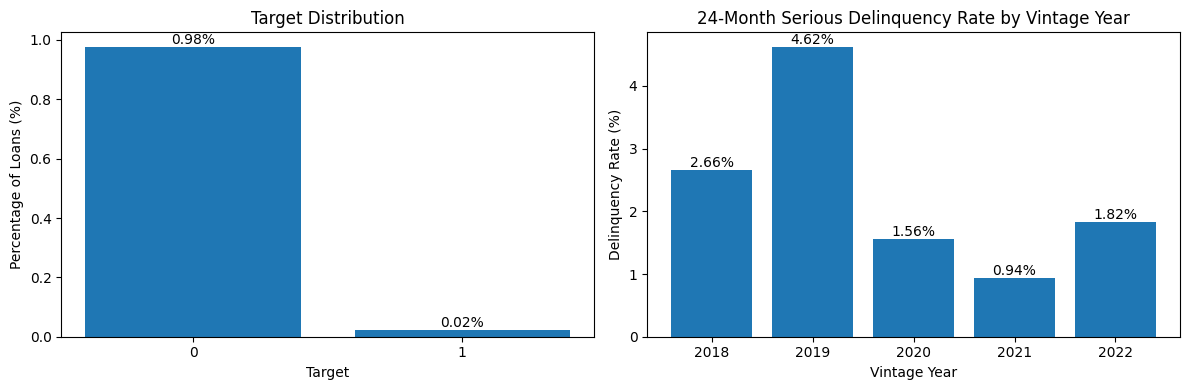

In [7]:
target_summary = (
    df['target']
    .value_counts()
    .rename_axis('target')
    .reset_index(name='count')
)
target_summary['percentage'] = target_summary['count'] / target_summary['count'].sum()

target_by_year = (
    df
    .groupby("vintage_year")
    .agg(
        num_loans=("target", "count"),
        delinquency_rate=("target", "mean"),
        num_bad_loans=("target", "sum")
    )
    .reset_index()
)
target_by_year["delinquency_rate_pct"] = target_by_year["delinquency_rate"] * 100

fig, axes = plt.subplots(1, 2, figsize = (12, 4))
axes[0].bar(
    target_summary['target'].astype(str),
    target_summary['percentage']
)
axes[0].set_title("Target Distribution")
axes[0].set_xlabel("Target")
axes[0].set_ylabel("Percentage of Loans (%)")

for i, value in enumerate(target_summary["percentage"]):
    axes[0].text(
        i,
        value,
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

axes[1].bar(
    target_by_year['vintage_year'].astype(str),
    target_by_year['delinquency_rate_pct']
)
axes[1].set_title("24-Month Serious Delinquency Rate by Vintage Year")
axes[1].set_xlabel("Vintage Year")
axes[1].set_ylabel("Delinquency Rate (%)")
for i, value in enumerate(target_by_year["delinquency_rate_pct"]):
    axes[1].text(
        i,
        value,
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

The left panel shows that serious delinquency is a highly imbalanced outcome, so accuracy alone is not an appropriate evaluation metric.

The right panel shows that delinquency rates vary across vintage years, supporting the use of a time-based train-validation-test split.


In [8]:
num_summary_by_target = (
    df
    .groupby("target")[num_cols]
    .agg(["mean", "median", "std"])
    .round(2)
)
num_summary_by_target[['credit_score', 'original_dti', 'original_ltv', 'original_interest_rate']]

credit_score               original_dti              original_ltv  \
               mean median    std         mean median   std         mean   
target                                                                     
0            750.47  759.0  44.64        34.97   36.0  9.59        72.97   
1            717.02  717.0  47.07        38.95   41.0  7.88        78.70   

                     original_interest_rate               
       median    std                   mean median   std  
target                                                    
0        77.0  17.69                   4.03   3.88  1.10  
1        80.0  15.69                   4.49   4.50  0.95

In this summary, loans with target = 1 have a lower average credit score and higher average DTI, LTV, and interest rate than loans with target = 0.

DTI measures the borrower’s debt burden relative to income, LTV measures the loan amount relative to the property value, and the interest rate reflects the borrowing cost at origination.

For example, the average credit score is 717.02 for delinquent loans, compared with 750.47 for non-delinquent loans. Meanwhile, delinquent loans have higher average DTI, LTV, and interest rates. These patterns are consistent with mortgage credit risk intuition. This suggests that loans that became seriously delinquent within 24 months tend to have weaker borrower credit quality, higher debt burden, higher leverage, and higher borrowing costs at origination.


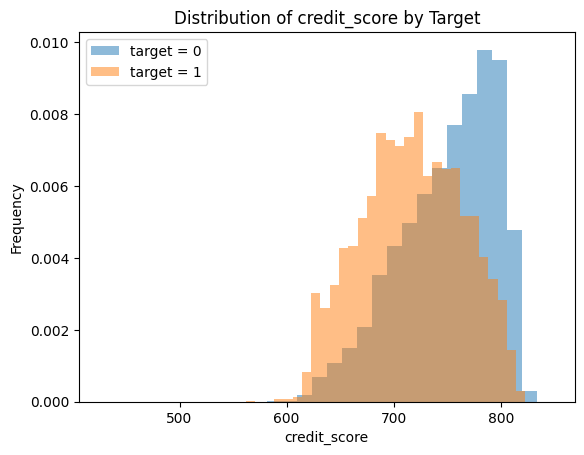

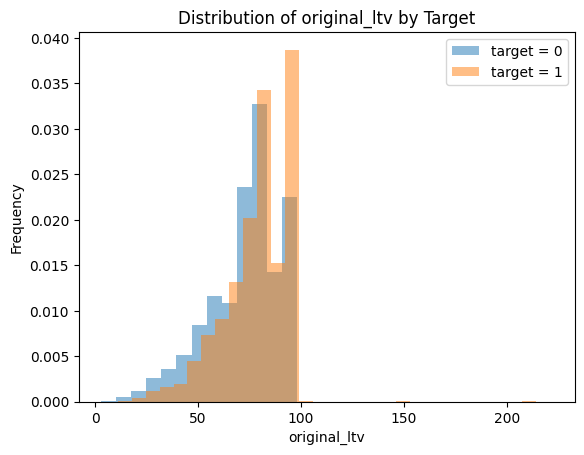

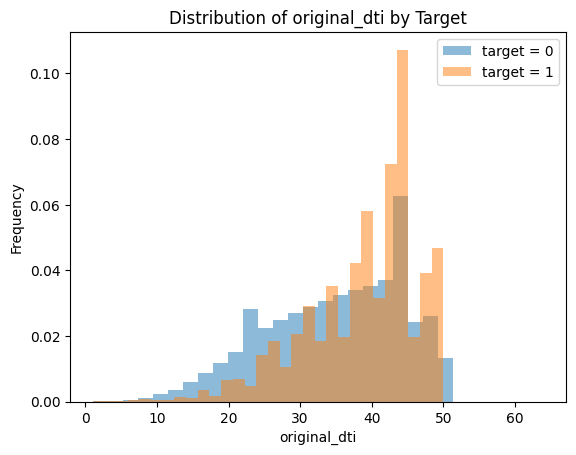

In [9]:
for col in ["credit_score", "original_ltv", "original_dti"]:
    df[df["target"] == 0][col].plot(kind="hist", bins=30, alpha=0.5, density=True, label="target = 0")
    df[df["target"] == 1][col].plot(kind="hist", bins=30, alpha=0.5, density=True, label="target = 1")
    plt.title(f"Distribution of {col} by Target")
    plt.xlabel(col)
    plt.legend()
    plt.show()

Across the three distribution plots, the delinquent loans show different patterns from the non-delinquent loans.

For credit score, the distribution of loans with target = 1 is shifted to the left, suggesting that seriously delinquent loans tend to have lower borrower credit quality. However, the two distributions still overlap substantially, indicating that credit score alone may not be sufficient for classification.

For original LTV, delinquent loans tend to have higher values, with more mass near the upper end of the distribution. This pattern suggests that leverage is related to mortgage credit risk.

Similarly, the distribution of original DTI for delinquent loans is more concentrated at higher DTI levels, suggesting that a higher borrower debt burden is associated with a higher likelihood of serious delinquency.

Overall, these patterns support including multiple origination indicators related to borrower credit quality, leverage, and debt burden in the model.


<Figure size 800x400 with 0 Axes>

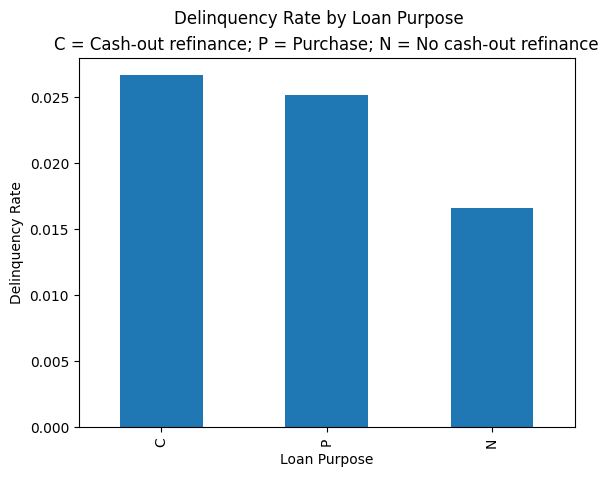

,loan_purpose,num_loans,delinquency_rate
0,C,56773,0.026632
2,P,126669,0.025128
1,N,66558,0.016617


In [10]:
loan_purpose_summary = (
    df
    .groupby("loan_purpose")
    .agg(
        num_loans = ('target', 'count'),
        delinquency_rate = ('target', 'mean'),
    )
    .reset_index()
    .sort_values(by='delinquency_rate', ascending=False)
)

plt.figure(figsize = (8, 4))
loan_purpose_summary.plot(
    x="loan_purpose",
    y="delinquency_rate",
    kind="bar",
    legend=False
)
plt.suptitle("Delinquency Rate by Loan Purpose")
plt.title("C = Cash-out refinance; P = Purchase; N = No cash-out refinance")
plt.xlabel("Loan Purpose")
plt.ylabel("Delinquency Rate")
plt.show()

loan_purpose_summary

Delinquency rates also vary by loan purpose. Cash-out refinance loans have the highest delinquency rate, followed by purchase loans, while no cash-out refinance loans have the lowest rate. This suggests that categorical origination features contain useful information for predicting mortgage credit risk.


## Methodology
**Method.** I compare five machine learning algorithms using separate training, validation, and test sets.

Hyperparameter tuning is presented **within each model's subsection**. To keep the comparison fair, every model is
- trained on the **same** `X_train / y_train` and evaluated on the **same** held-out `X_test / y_test`;
- tuned with a **time-aware** validation procedure (`TimeSeriesSplit`) so no future information leaks into validation;
- scored with the **same** `evaluate_model()` helper (Section 4.1).

### Model Overview
I compare five algorithms with complementary modeling assumptions:

| Model | Practice focus |
|---|---|
| **Logistic Regression** | Interpretable linear probability baseline |
| **Random Forest** | Nonlinear bagged tree ensemble |
| **Linear SVM** | Margin-based linear classifier |
| **Neural Network (MLP)** | Nonlinear multilayer classifier |
| **XGBoost** | Gradient-boosted tree ensemble |


In [11]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix
)

def evaluate_model(name, y_true, y_score, threshold=0.5, ax_roc=None, ax_pr=None):
    y_score = np.asarray(y_score)
    y_pred = (y_score >= threshold).astype(int)
    metrics = {
        "Model": name,
        "ROC_AUC": roc_auc_score(y_true, y_score),
        "PR_AUC": average_precision_score(y_true, y_score),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "Threshold": threshold,
    }
    fpr, tpr, _ = roc_curve(y_true, y_score)
    if ax_roc is not None:
        ax_roc.plot(fpr, tpr, label=f"{name} (AUC={metrics['ROC_AUC']:.3f})")
    prec, rec, _ = precision_recall_curve(y_true, y_score)
    if ax_pr is not None:
        ax_pr.plot(rec, prec, label=f"{name} (AP={metrics['PR_AUC']:.3f})")
    return metrics

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

def make_preprocessor(scale=False):
    """scale=True for logistic/SVM/NN；scale=False for XGBoost/RF"""
    num_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale:
        num_steps.append(("scaler", StandardScaler()))
    return ColumnTransformer(transformers=[
        ("num", Pipeline(num_steps), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), cat_cols),
    ])

Before fitting the individual machine learning models, I first import the basic packages, preprocessing tools, model classes, and evaluation metrics that will be used throughout the modeling section. This setup step helps keep the later model sections cleaner and avoids repeating the same imports multiple times.


In [13]:
%%capture
%pip install xgboost imbalanced-learn

In [14]:
# Preprocessing and pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Model selection
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

# Class imbalance tools
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# Reproducibility
RANDOM_SEED = 42

### Logistic Regression


**Practice goal.**

Logistic Regression is used as the first model because the target variable is binary, indicating whether a mortgage loan becomes seriously delinquent within the first 24 months. The model estimates the probability of delinquency based on borrower, loan, and property characteristics. It also provides an interpretable baseline because the coefficients show how each feature is associated with higher or lower delinquency risk.

**Why appropriate here.**

Logistic Regression is appropriate for this project because the Freddie Mac mortgage dataset contains structured loan-level features. Numerical variables such as credit score, DTI, LTV, CLTV, interest rate, original UPB, and loan term can be standardized, while categorical variables such as loan purpose, occupancy status, property type, channel, and property state can be one-hot encoded.

Since serious delinquency is a rare event, I use class-weighted Logistic Regression to account for class imbalance. Model performance is evaluated using ROC-AUC, PR-AUC, precision, recall, and F1-score, and the classification threshold is selected using the validation set.


In [15]:
# Model 1: Logistic Regression

lr_class_balance_summary = pd.DataFrame({
    "dataset": ["train", "validation", "test"],
    "n_observations": [len(y_train), len(y_valid), len(y_test)],
    "n_positive": [int(y_train.sum()), int(y_valid.sum()), int(y_test.sum())],
    "n_negative": [
        int(len(y_train) - y_train.sum()),
        int(len(y_valid) - y_valid.sum()),
        int(len(y_test) - y_test.sum())
    ],
    "positive_rate": [y_train.mean(), y_valid.mean(), y_test.mean()]
})

lr_class_balance_summary

,dataset,n_observations,n_positive,n_negative,positive_rate
0,train,150000,4421,145579,0.029473
1,validation,50000,469,49531,0.009380
2,test,50000,911,49089,0.018220


#### Baseline Logistic Regression Model

I first fit a baseline Logistic Regression model using L2 regularization. The preprocessing pipeline standardizes numerical variables and one-hot encodes categorical variables. Because the positive class is rare, `class_weight="balanced"` is used to give more weight to delinquent loans during training.


In [16]:
lr_baseline_pipeline = Pipeline(steps=[
    ("preprocessor", make_preprocessor(scale=True)),
    ("model", LogisticRegression(
        penalty="l2",
        C=1.0,
        class_weight="balanced",
        solver="liblinear",
        max_iter=1000,
        random_state=RANDOM_SEED
    ))
])

lr_baseline_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['credit_score',
                                                   'mortgage_insurance_percent',
                                                   'number_of_units',
                                                   'original_cltv',
                                                   'original_dti',
                                                   'original_upb',
                                                   'original_ltv',
                                                   'original_interest_rate',
                                                   'original_loan_term',
                                                   'number_of_borrowe...
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['first_time_homebuyer_flag',
                                                   'occupancy_status',
                                                   'channel',
                                                   'amortization_type',
                                                   'property_state',
                                                   'property_type',
                                                   'loan_purpose'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42, solver='liblinear'))])

#### Baseline Validation Evaluation

The baseline Logistic Regression model is evaluated on the validation set. Since the default threshold of 0.5 may not be suitable for an imbalanced classification problem, the probability threshold is selected based on the F1-score on the validation set.


In [17]:
def lr_find_best_f1_threshold(y_true, y_score):
    """
    Select the probability threshold that maximizes F1-score
    on the validation set.
    """
    precision, recall, thresholds = precision_recall_curve(y_true, y_score)

    precision_for_thresholds = precision[:-1]
    recall_for_thresholds = recall[:-1]

    f1_scores = (
        2 * precision_for_thresholds * recall_for_thresholds /
        (precision_for_thresholds + recall_for_thresholds + 1e-12)
    )

    best_index = np.argmax(f1_scores)
    best_threshold = thresholds[best_index]
    best_f1 = f1_scores[best_index]

    return best_threshold, best_f1

In [18]:
lr_baseline_valid_prob = lr_baseline_pipeline.predict_proba(X_valid)[:, 1]

lr_baseline_best_threshold, lr_baseline_best_valid_f1 = lr_find_best_f1_threshold(
    y_valid,
    lr_baseline_valid_prob
)

print("Baseline Logistic Regression best validation threshold:", lr_baseline_best_threshold)
print("Baseline Logistic Regression best validation F1:", lr_baseline_best_valid_f1)

lr_baseline_valid_perform = evaluate_model(
    name="Logistic Regression baseline_validation set",
    y_true=y_valid,
    y_score=lr_baseline_valid_prob,
    threshold=lr_baseline_best_threshold
)

lr_baseline_valid_df = pd.DataFrame([lr_baseline_valid_perform])
lr_baseline_valid_df

Baseline Logistic Regression best validation threshold: 0.7415743514665926
Baseline Logistic Regression best validation F1: 0.07854137447361186


,Model,ROC_AUC,PR_AUC,Precision,Recall,F1,Threshold
0,Logistic Regression baseline_validation set,0.782054,0.033976,0.058516,0.119403,0.078541,0.741574


#### Hyperparameter Tuning

I tune the Logistic Regression model by testing different values of `C`, which controls the strength of regularization. TimeSeriesSplit is used so that the cross-validation process respects the chronological structure of the mortgage data. Average precision is used as the scoring metric because the target class is imbalanced.


In [19]:
from sklearn.model_selection import TimeSeriesSplit

lr_train_sorted = train.sort_values(["vintage_year", "first_payment_date"]).copy()

lr_X_train_search = lr_train_sorted[feature_cols]
lr_y_train_search = lr_train_sorted["target"].astype(int)

lr_search_pipeline = Pipeline(steps=[
    ("preprocessor", make_preprocessor(scale=True)),
    ("model", LogisticRegression(
        class_weight="balanced",
        solver="liblinear",
        max_iter=1000,
        random_state=RANDOM_SEED
    ))
])

lr_param_grid = {
    "model__C": [0.01, 0.1, 1.0, 10.0]
}

lr_tscv = TimeSeriesSplit(n_splits=3)

lr_search = GridSearchCV(
    estimator=lr_search_pipeline,
    param_grid=lr_param_grid,
    scoring="average_precision",
    cv=lr_tscv,
    n_jobs=-1,
    verbose=1,
    refit=True
)

lr_search.fit(lr_X_train_search, lr_y_train_search)

print("Best CV PR-AUC:", lr_search.best_score_)
print("Best parameters:")
print(lr_search.best_params_)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best CV PR-AUC: 0.07757655413908636
Best parameters:
{'model__C': 0.01}


#### Tuned Logistic Regression Evaluation

After hyperparameter tuning, the best Logistic Regression model is evaluated on the validation set and then on the held-out test set. The classification threshold is selected from the validation set and then applied to the test set to avoid using test information during model selection.


In [20]:
lr_best = lr_search.best_estimator_

lr_tuned_valid_prob = lr_best.predict_proba(X_valid)[:, 1]

lr_tuned_best_threshold, lr_tuned_best_valid_f1 = lr_find_best_f1_threshold(
    y_valid,
    lr_tuned_valid_prob
)

print("Tuned Logistic Regression best validation threshold:", lr_tuned_best_threshold)
print("Tuned Logistic Regression best validation F1:", lr_tuned_best_valid_f1)

lr_tuned_valid_perform = evaluate_model(
    name="Logistic Regression tuned_validation set",
    y_true=y_valid,
    y_score=lr_tuned_valid_prob,
    threshold=lr_tuned_best_threshold
)

lr_tuned_valid_df = pd.DataFrame([lr_tuned_valid_perform])
lr_tuned_valid_df

Tuned Logistic Regression best validation threshold: 0.7330083619471652
Tuned Logistic Regression best validation F1: 0.07821982467927083


,Model,ROC_AUC,PR_AUC,Precision,Recall,F1,Threshold
0,Logistic Regression tuned_validation set,0.784702,0.034677,0.057199,0.123667,0.07822,0.733008


In [21]:
lr_tuned_test_prob = lr_best.predict_proba(X_test)[:, 1]

lr_tuned_test_perform = evaluate_model(
    name="Logistic Regression tuned_test set",
    y_true=y_test,
    y_score=lr_tuned_test_prob,
    threshold=lr_tuned_best_threshold
)

lr_tuned_test_df = pd.DataFrame([lr_tuned_test_perform])
lr_tuned_test_df

,Model,ROC_AUC,PR_AUC,Precision,Recall,F1,Threshold
0,Logistic Regression tuned_test set,0.75132,0.053751,0.047712,0.560922,0.087944,0.733008


In [22]:
lr_tuned_test_pred = (
    lr_tuned_test_prob >= lr_tuned_best_threshold
).astype(int)

print("Tuned Logistic Regression Test Confusion Matrix:")
print(confusion_matrix(y_test, lr_tuned_test_pred))

print("\nTuned Logistic Regression Test Classification Report:")
print(classification_report(y_test, lr_tuned_test_pred, zero_division=0))

Tuned Logistic Regression Test Confusion Matrix:
[[38890 10199]
 [  400   511]]

Tuned Logistic Regression Test Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.79      0.88     49089
           1       0.05      0.56      0.09       911

    accuracy                           0.79     50000
   macro avg       0.52      0.68      0.48     50000
weighted avg       0.97      0.79      0.87     50000



#### ROC Curve and Precision-Recall Curve

The ROC curve and Precision-Recall curve are plotted to evaluate the model's ranking performance. PR-AUC is especially important in this project because serious delinquency is a rare event.


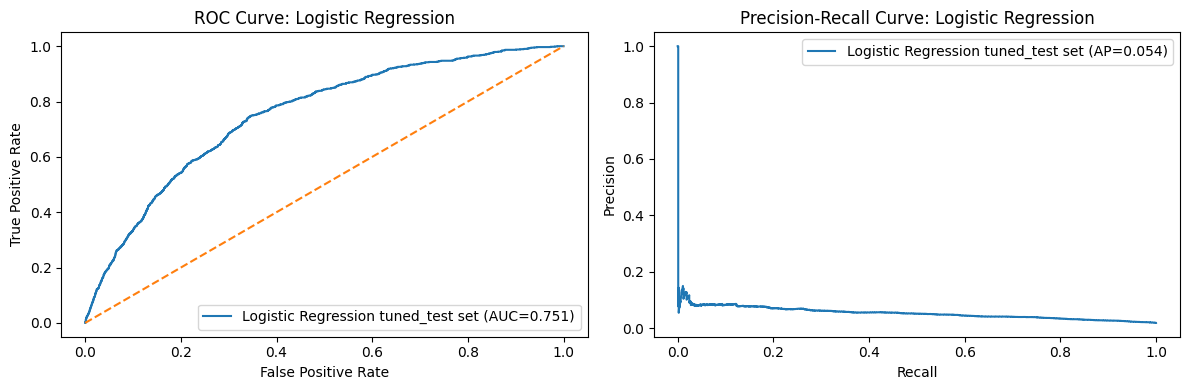

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

evaluate_model(
    name="Logistic Regression tuned_test set",
    y_true=y_test,
    y_score=lr_tuned_test_prob,
    threshold=lr_tuned_best_threshold,
    ax_roc=axes[0],
    ax_pr=axes[1]
)

axes[0].plot([0, 1], [0, 1], linestyle="--")
axes[0].set_title("ROC Curve: Logistic Regression")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

axes[1].set_title("Precision-Recall Curve: Logistic Regression")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.tight_layout()
plt.show()

#### Coefficient Interpretation

Logistic Regression coefficients can be used to interpret the direction of each feature's relationship with delinquency risk. Positive coefficients indicate higher predicted delinquency risk, while negative coefficients indicate lower predicted delinquency risk.


In [24]:
lr_feature_names = lr_best.named_steps["preprocessor"].get_feature_names_out()
lr_coefficients = lr_best.named_steps["model"].coef_[0]

lr_coef_df = pd.DataFrame({
    "feature": lr_feature_names,
    "coefficient": lr_coefficients
})

lr_coef_df["feature_clean"] = (
    lr_coef_df["feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

lr_coef_df["abs_coefficient"] = lr_coef_df["coefficient"].abs()

lr_top_positive = (
    lr_coef_df
    .sort_values("coefficient", ascending=False)
    .head(15)
)

lr_top_negative = (
    lr_coef_df
    .sort_values("coefficient", ascending=True)
    .head(15)
)

print("Top positive coefficients:")
display(lr_top_positive[["feature_clean", "coefficient"]])

print("Top negative coefficients:")
display(lr_top_negative[["feature_clean", "coefficient"]])

Top positive coefficients:


,feature_clean,coefficient
54,property_state_NY,0.543031
51,property_state_NJ,0.542014
25,property_state_CT,0.410113
28,property_state_FL,0.397373
4,original_dti,0.369482
3,original_cltv,0.343594
7,original_interest_rate,0.303148
26,property_state_DC,0.273387
38,property_state_LA,0.259035
75,property_type_MH,0.243614


Top negative coefficients:


,feature_clean,coefficient
0,credit_score,-0.578819
50,property_state_NH,-0.399092
32,property_state_IA,-0.317567
65,property_state_UT,-0.314976
70,property_state_WI,-0.308763
20,property_state_AL,-0.295163
49,property_state_NE,-0.281702
80,loan_purpose_P,-0.275058
21,property_state_AR,-0.264949
27,property_state_DE,-0.261125


#### Logistic Regression Summary

The final summary table reports the selected hyperparameter, classification threshold, and key test-set metrics for the tuned Logistic Regression model.


In [25]:
lr_final_summary_df = pd.DataFrame({
    "model": ["Final Tuned Logistic Regression"],
    "best_C": [lr_search.best_params_["model__C"]],
    "selected_threshold": [lr_tuned_best_threshold],
    "test_roc_auc": [roc_auc_score(y_test, lr_tuned_test_prob)],
    "test_pr_auc": [average_precision_score(y_test, lr_tuned_test_prob)],
    "test_accuracy": [accuracy_score(y_test, lr_tuned_test_pred)],
    "test_precision": [precision_score(y_test, lr_tuned_test_pred, zero_division=0)],
    "test_recall": [recall_score(y_test, lr_tuned_test_pred, zero_division=0)],
    "test_f1": [f1_score(y_test, lr_tuned_test_pred, zero_division=0)]
})

lr_final_summary_df.round(4)

,model,best_C,selected_threshold,test_roc_auc,test_pr_auc,test_accuracy,test_precision,test_recall,test_f1
0,Final Tuned Logistic Regression,0.01,0.733,0.7513,0.0538,0.788,0.0477,0.5609,0.0879


The final tuned Logistic Regression model selected `C = 0.01`, which indicates relatively strong regularization. The selected classification threshold from the validation set was 0.733. On the validation set, the tuned model achieved a ROC-AUC of 0.7847 and a PR-AUC of 0.0347, with precision of 0.0572, recall of 0.1237, and F1-score of 0.0782.

On the held-out test set, the tuned Logistic Regression model achieved a ROC-AUC of 0.7513 and a PR-AUC of 0.0538. The test accuracy was 0.7880, precision was 0.0477, recall was 0.5609, and F1-score was 0.0879. The relatively high recall shows that the model is able to identify a meaningful portion of seriously delinquent loans, but the low precision indicates that many loans predicted as delinquent are not actually delinquent. This pattern is expected because serious delinquency is a rare event in the dataset.

The ROC curve shows that the model has moderate ranking ability, with performance clearly above the random classifier line. However, the Precision-Recall curve remains low, which reflects the difficulty of predicting a rare positive class. Since PR-AUC focuses on the positive class, it is especially useful for evaluating this delinquency prediction task.

The coefficient results also provide interpretable patterns. Features with positive coefficients, such as higher original DTI, higher CLTV, higher interest rate, and several property state indicators, are associated with higher predicted delinquency risk. In contrast, credit score has the strongest negative coefficient, meaning that higher credit scores are associated with lower predicted delinquency risk. Other negative coefficients, such as number of borrowers and some property type or state indicators, are associated with lower predicted delinquency risk. These coefficients should be interpreted as directional associations rather than causal effects.


### Random Forest


**Practice goal.**

I include a Random Forest classifier as a nonlinear tree-based ensemble model in my model comparison. Mortgage delinquency risk may depend on nonlinear relationships and interactions among borrower credit quality, leverage, debt burden, loan pricing, loan purpose, occupancy status, property type, and geographic characteristics. For example, the effect of a high loan-to-value ratio may be different for borrowers with high versus low credit scores, and categorical features such as loan purpose or occupancy status may interact with numerical borrower characteristics.

Random Forest is appropriate for this project because it combines many decision trees through bagging, which can reduce the variance of a single decision tree and improve out-of-sample stability. It can capture nonlinear effects and feature interactions without requiring me to manually specify interaction terms. In addition, Random Forest provides feature importance measures, which help me interpret which origination variables are most useful for predicting serious delinquency.

Since serious delinquency is a rare event in this dataset, I do not rely on accuracy alone. Instead, I evaluate the model using ROC-AUC, PR-AUC, precision, recall, and F1-score. I also select the probability threshold using the validation set and then apply that threshold to the held-out test set.


In [26]:
# Random Forest section: check class distribution
rf_class_balance_summary = pd.DataFrame({
    "dataset": ["train", "validation", "test"],
    "n_observations": [len(y_train), len(y_valid), len(y_test)],
    "n_positive": [int(y_train.sum()), int(y_valid.sum()), int(y_test.sum())],
    "n_negative": [
        int(len(y_train) - y_train.sum()),
        int(len(y_valid) - y_valid.sum()),
        int(len(y_test) - y_test.sum())
    ],
    "positive_rate": [y_train.mean(), y_valid.mean(), y_test.mean()]
})

rf_class_balance_summary

,dataset,n_observations,n_positive,n_negative,positive_rate
0,train,150000,4421,145579,0.029473
1,validation,50000,469,49531,0.009380
2,test,50000,911,49089,0.018220


Before fitting the Random Forest model, I first check the class distribution in the training, validation, and test sets. This step is important because serious delinquency is a rare event. If the positive class is very small, a model can achieve high accuracy simply by predicting most loans as non-delinquent. Therefore, the later evaluation focuses on ranking and rare-event classification metrics, including ROC-AUC, PR-AUC, precision, recall, and F1-score.


In [27]:
def rf_find_best_f1_threshold(rf_y_true, rf_y_pred_prob):
    """
    Select the probability threshold that maximizes the F1-score
    on the validation set.
    """
    rf_pr_precision, rf_pr_recall, rf_pr_thresholds = precision_recall_curve(
        rf_y_true,
        rf_y_pred_prob
    )
    
    rf_f1_scores = (
        2 * rf_pr_precision * rf_pr_recall /
        (rf_pr_precision + rf_pr_recall + 1e-12)
    )
    
    # The last precision/recall point does not have a corresponding threshold
    rf_best_index = np.argmax(rf_f1_scores[:-1])
    rf_best_threshold = rf_pr_thresholds[rf_best_index]
    rf_best_f1 = rf_f1_scores[rf_best_index]
    
    return rf_best_threshold, rf_best_f1


def rf_evaluate_binary_classifier(rf_y_true, rf_y_pred_prob, rf_threshold=0.5, rf_model_name="Random Forest"):
    """
    Evaluate a binary classifier using both threshold-free and threshold-based metrics.
    """
    rf_y_pred_label = (rf_y_pred_prob >= rf_threshold).astype(int)
    
    rf_results = {
        "model": rf_model_name,
        "threshold": rf_threshold,
        "roc_auc": roc_auc_score(rf_y_true, rf_y_pred_prob),
        "pr_auc": average_precision_score(rf_y_true, rf_y_pred_prob),
        "accuracy": accuracy_score(rf_y_true, rf_y_pred_label),
        "precision": precision_score(rf_y_true, rf_y_pred_label, zero_division=0),
        "recall": recall_score(rf_y_true, rf_y_pred_label, zero_division=0),
        "f1": f1_score(rf_y_true, rf_y_pred_label, zero_division=0)
    }
    
    return rf_results

The following helper functions are used only for the Random Forest section. To avoid overwriting variables or functions from the other model sections, all function and variable names in this section use the `rf_` prefix.

The first helper function selects the probability threshold that maximizes the validation-set F1-score. This is useful because the default threshold of 0.5 may not be appropriate for an imbalanced classification problem. The second helper function reports both threshold-free metrics, such as ROC-AUC and PR-AUC, and threshold-based metrics, such as precision, recall, and F1-score.


#### Baseline Random Forest Model

I first fit a baseline Random Forest model. The model uses 200 trees, the square root of the number of features at each split, and class-balanced weights to account for the rare positive class. Since Random Forest is a tree-based model, numerical feature scaling is not required. Therefore, I use the shared preprocessing function with `scale=False`, which imputes missing numerical values and one-hot encodes categorical variables.

The baseline model is trained on the original training set. Unlike the MLP section, I do not oversample the training data here. Instead, I use `class_weight="balanced"` so that the Random Forest gives more weight to the minority class during training.


In [28]:
rf_baseline_pipeline = Pipeline(steps=[
    ("preprocessor", make_preprocessor(scale=False)),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_leaf=1,
        max_features="sqrt",
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_SEED
    ))
])

rf_baseline_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['credit_score',
                                                   'mortgage_insurance_percent',
                                                   'number_of_units',
                                                   'original_cltv',
                                                   'original_dti',
                                                   'original_upb',
                                                   'original_ltv',
                                                   'original_interest_rate',
                                                   'original_loan_term',
                                                   'number_of_borrowers']),
                                                 ('cat',
                                                  Pipeline(steps=...r',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['first_time_homebuyer_flag',
                                                   'occupancy_status',
                                                   'channel',
                                                   'amortization_type',
                                                   'property_state',
                                                   'property_type',
                                                   'loan_purpose'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [29]:
rf_baseline_valid_pred_prob = rf_baseline_pipeline.predict_proba(X_valid)[:, 1]

rf_baseline_best_threshold, rf_baseline_best_valid_f1 = rf_find_best_f1_threshold(
    y_valid,
    rf_baseline_valid_pred_prob
)

print("Baseline Random Forest best validation threshold:", rf_baseline_best_threshold)
print("Baseline Random Forest best validation F1:", rf_baseline_best_valid_f1)

rf_baseline_valid_results = rf_evaluate_binary_classifier(
    y_valid,
    rf_baseline_valid_pred_prob,
    rf_threshold=rf_baseline_best_threshold,
    rf_model_name="Baseline Random Forest"
)

rf_baseline_valid_results_df = pd.DataFrame([rf_baseline_valid_results])
rf_baseline_valid_results_df

Baseline Random Forest best validation threshold: 0.075
Baseline Random Forest best validation F1: 0.055648302726381084


,model,threshold,roc_auc,pr_auc,accuracy,precision,recall,f1
0,Baseline Random Forest,0.075,0.702573,0.020463,0.96606,0.037651,0.10661,0.055648


The baseline Random Forest is evaluated on the validation set. I first obtain predicted probabilities for serious delinquency and then select the probability threshold that maximizes the validation F1-score. This validation-based threshold is used because the default 0.5 threshold may be too high in a rare-event setting.

The validation results provide the first benchmark for the Random Forest model. In particular, ROC-AUC measures the model's ability to rank delinquent loans above non-delinquent loans, while PR-AUC is especially useful when the positive class is rare. Precision, recall, and F1-score summarize the classification performance after applying the selected threshold.


#### Random Forest Hyperparameter Tuning

After fitting the baseline Random Forest, I tune several key hyperparameters using the 2021 validation set. The tuned parameters include the number of trees, maximum tree depth, and minimum number of samples required at each leaf node.

The maximum depth and minimum leaf size control the complexity of individual trees. Very deep trees with very small leaves may overfit the training data, while shallower trees or larger leaf sizes can improve generalization. Because this dataset is large, I use a limited tuning grid instead of a very large exhaustive search.

Although the overall project framework mentions time-aware validation, the Random Forest section uses the fixed 2021 validation set that was already created in the shared data split. This still preserves the temporal ordering of the data because the model is trained on 2018–2020 loans, tuned on 2021 loans, and finally evaluated on the held-out 2022 test set.

The final Random Forest specification is selected based on validation F1-score after threshold tuning, while ROC-AUC and PR-AUC are also reported as threshold-free performance measures.


In [30]:
rf_tuned_metrics_list = []

rf_n_estimators_options = [200, 400]
rf_max_depth_options = [6, 10, None]
rf_min_samples_leaf_options = [20, 50, 100]
rf_max_features_options = ["sqrt"]

for rf_n_estimators in rf_n_estimators_options:
    for rf_max_depth in rf_max_depth_options:
        for rf_min_samples_leaf in rf_min_samples_leaf_options:
            for rf_max_features in rf_max_features_options:
                
                rf_tune_pipeline = Pipeline(steps=[
                    ("preprocessor", make_preprocessor(scale=False)),
                    ("classifier", RandomForestClassifier(
                        n_estimators=rf_n_estimators,
                        max_depth=rf_max_depth,
                        min_samples_leaf=rf_min_samples_leaf,
                        max_features=rf_max_features,
                        class_weight="balanced",
                        n_jobs=-1,
                        random_state=RANDOM_SEED
                    ))
                ])
                
                rf_tune_pipeline.fit(X_train, y_train)
                
                print(
                    "Finished:",
                    "n_estimators =", rf_n_estimators,
                    "max_depth =", rf_max_depth,
                    "min_samples_leaf =", rf_min_samples_leaf,
                    "max_features =", rf_max_features
                )
                
                rf_tune_valid_pred_prob = rf_tune_pipeline.predict_proba(X_valid)[:, 1]
                
                rf_tune_best_threshold, rf_tune_best_valid_f1 = rf_find_best_f1_threshold(
                    y_valid,
                    rf_tune_valid_pred_prob
                )
                
                rf_tune_valid_metrics = rf_evaluate_binary_classifier(
                    y_valid,
                    rf_tune_valid_pred_prob,
                    rf_threshold=rf_tune_best_threshold,
                    rf_model_name="Random Forest tuning"
                )
                
                rf_tune_valid_metrics["n_estimators"] = rf_n_estimators
                rf_tune_valid_metrics["max_depth"] = str(rf_max_depth)
                rf_tune_valid_metrics["min_samples_leaf"] = rf_min_samples_leaf
                rf_tune_valid_metrics["max_features"] = rf_max_features
                
                rf_tuned_metrics_list.append(rf_tune_valid_metrics)

rf_tuning_results_df = pd.DataFrame(rf_tuned_metrics_list)
rf_tuning_results_df = rf_tuning_results_df.sort_values(
    by="f1",
    ascending=False
).reset_index(drop=True)

rf_tuning_results_df["max_depth"] = rf_tuning_results_df["max_depth"].fillna("None")

rf_tuning_results_df.head(10)

Finished: n_estimators = 200 max_depth = 6 min_samples_leaf = 20 max_features = sqrt
Finished: n_estimators = 200 max_depth = 6 min_samples_leaf = 50 max_features = sqrt
Finished: n_estimators = 200 max_depth = 6 min_samples_leaf = 100 max_features = sqrt
Finished: n_estimators = 200 max_depth = 10 min_samples_leaf = 20 max_features = sqrt
Finished: n_estimators = 200 max_depth = 10 min_samples_leaf = 50 max_features = sqrt
Finished: n_estimators = 200 max_depth = 10 min_samples_leaf = 100 max_features = sqrt
Finished: n_estimators = 200 max_depth = None min_samples_leaf = 20 max_features = sqrt
Finished: n_estimators = 200 max_depth = None min_samples_leaf = 50 max_features = sqrt
Finished: n_estimators = 200 max_depth = None min_samples_leaf = 100 max_features = sqrt
Finished: n_estimators = 400 max_depth = 6 min_samples_leaf = 20 max_features = sqrt
Finished: n_estimators = 400 max_depth = 6 min_samples_leaf = 50 max_features = sqrt
Finished: n_estimators = 400 max_depth = 6 min_sam

,model,threshold,roc_auc,pr_auc,accuracy,precision,recall,f1,n_estimators,max_depth,min_samples_leaf,max_features
0,Random Forest tuning,0.606580,0.774780,0.030645,0.97162,0.058550,0.134328,0.081553,200,None,100,sqrt
1,Random Forest tuning,0.586007,0.768018,0.030230,0.97052,0.057269,0.138593,0.081047,400,6,100,sqrt
2,Random Forest tuning,0.606522,0.765039,0.030186,0.97906,0.068657,0.098081,0.080773,400,6,20,sqrt
3,Random Forest tuning,0.610437,0.772249,0.030002,0.97262,0.058824,0.127932,0.080591,400,None,100,sqrt
4,Random Forest tuning,0.569760,0.771056,0.030224,0.96738,0.054448,0.151386,0.080090,400,None,50,sqrt
5,Random Forest tuning,0.593177,0.766316,0.030192,0.97330,0.059063,0.123667,0.079945,400,6,50,sqrt
6,Random Forest tuning,0.595597,0.768313,0.030441,0.97558,0.061772,0.113006,0.079879,200,6,100,sqrt
7,Random Forest tuning,0.599796,0.771142,0.030156,0.97318,0.058704,0.123667,0.079616,400,10,20,sqrt
8,Random Forest tuning,0.597862,0.765137,0.030195,0.97564,0.060961,0.110874,0.078669,200,6,20,sqrt
9,Random Forest tuning,0.596630,0.770066,0.030035,0.96968,0.054468,0.136461,0.077859,400,10,50,sqrt


In [31]:
rf_best_metrics = rf_tuning_results_df.iloc[0]

rf_best_n_estimators = int(rf_best_metrics["n_estimators"])
rf_best_max_depth_str = rf_best_metrics["max_depth"]
rf_best_max_depth = None if rf_best_max_depth_str == "None" else int(rf_best_max_depth_str)
rf_best_min_samples_leaf = int(rf_best_metrics["min_samples_leaf"])
rf_best_max_features = rf_best_metrics["max_features"]

print("Best Random Forest hyperparameters:")
print("n_estimators:", rf_best_n_estimators)
print("max_depth:", rf_best_max_depth)
print("min_samples_leaf:", rf_best_min_samples_leaf)
print("max_features:", rf_best_max_features)

rf_best_metrics

Best Random Forest hyperparameters:
n_estimators: 200
max_depth: None
min_samples_leaf: 100
max_features: sqrt


model               Random Forest tuning
threshold                        0.60658
roc_auc                          0.77478
pr_auc                          0.030645
accuracy                         0.97162
precision                        0.05855
recall                          0.134328
f1                              0.081553
n_estimators                         200
max_depth                           None
min_samples_leaf                     100
max_features                        sqrt
Name: 0, dtype: object

The tuning results show which Random Forest specification performs best on the validation set after threshold selection. The selected model balances predictive performance and model complexity. A more complex Random Forest may fit the training data more closely, but it does not necessarily produce better validation performance in this rare-event classification setting. Therefore, the final Random Forest model is chosen based on validation F1-score rather than training accuracy.


#### Final Random Forest Test Evaluation

Based on the validation tuning results, I refit the final Random Forest model using the selected hyperparameter specification. The probability threshold is selected using the validation set and then applied to the 2022 test set. This procedure keeps the test set fully held out for final out-of-sample evaluation.

The final test results report both threshold-free and threshold-based metrics. ROC-AUC measures the model's ranking ability, while PR-AUC is more informative for rare-event prediction. Precision, recall, and F1-score describe the trade-off between identifying serious delinquency cases and avoiding false positives.


In [32]:
rf_final_pipeline = Pipeline(steps=[
    ("preprocessor", make_preprocessor(scale=False)),
    ("classifier", RandomForestClassifier(
        n_estimators=rf_best_n_estimators,
        max_depth=rf_best_max_depth,
        min_samples_leaf=rf_best_min_samples_leaf,
        max_features=rf_best_max_features,
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_SEED
    ))
])

rf_final_pipeline.fit(X_train, y_train)

rf_final_valid_pred_prob = rf_final_pipeline.predict_proba(X_valid)[:, 1]

rf_final_best_threshold, rf_final_best_valid_f1 = rf_find_best_f1_threshold(
    y_valid,
    rf_final_valid_pred_prob
)

print("Final Random Forest validation threshold:", rf_final_best_threshold)
print("Final Random Forest validation F1:", rf_final_best_valid_f1)

rf_final_valid_results = rf_evaluate_binary_classifier(
    y_valid,
    rf_final_valid_pred_prob,
    rf_threshold=rf_final_best_threshold,
    rf_model_name="Final Random Forest - Validation"
)

rf_final_valid_results_df = pd.DataFrame([rf_final_valid_results])
rf_final_valid_results_df

Final Random Forest validation threshold: 0.6065795623313841
Final Random Forest validation F1: 0.08155339805782962


,model,threshold,roc_auc,pr_auc,accuracy,precision,recall,f1
0,Final Random Forest - Validation,0.60658,0.77478,0.030645,0.97162,0.05855,0.134328,0.081553


In [33]:
rf_final_test_pred_prob = rf_final_pipeline.predict_proba(X_test)[:, 1]

rf_final_test_results = rf_evaluate_binary_classifier(
    y_test,
    rf_final_test_pred_prob,
    rf_threshold=rf_final_best_threshold,
    rf_model_name="Final Random Forest - Test"
)

rf_final_test_results_df = pd.DataFrame([rf_final_test_results])
rf_final_test_results_df

,model,threshold,roc_auc,pr_auc,accuracy,precision,recall,f1
0,Final Random Forest - Test,0.60658,0.747519,0.045829,0.78382,0.046546,0.557629,0.08592


The final Random Forest model achieved a test ROC-AUC of 0.7475 and a PR-AUC of 0.0458. Since serious delinquency is a rare event in the test set, the PR-AUC is much lower than the ROC-AUC, but it is still above the base positive rate. Using the threshold selected from the validation set, the model achieved a recall of 0.5576 and a precision of 0.0465 on the test set.

This result suggests that the Random Forest model is better at identifying a relatively large share of seriously delinquent loans than at producing highly precise positive predictions. In a mortgage risk monitoring context, this trade-off may be acceptable if the goal is to flag potentially risky loans for further review. However, if the model were used for direct underwriting decisions, the low precision would require caution because many loans flagged as high-risk would not actually become seriously delinquent.


In [34]:
rf_final_test_pred_label = (rf_final_test_pred_prob >= rf_final_best_threshold).astype(int)

rf_confusion_matrix = confusion_matrix(y_test, rf_final_test_pred_label)

rf_confusion_matrix_df = pd.DataFrame(
    rf_confusion_matrix,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

rf_confusion_matrix_df

,Predicted 0,Predicted 1
Actual 0,38683,10406
Actual 1,403,508


The confusion matrix shows the number of true negatives, false positives, false negatives, and true positives on the test set. In the context of mortgage credit risk, false negatives correspond to seriously delinquent loans that the model fails to identify, while false positives correspond to loans that are flagged as high-risk but do not become seriously delinquent. The relative cost of these two errors depends on the business application. For example, a risk monitoring system may prefer higher recall, while an underwriting decision system may require higher precision.


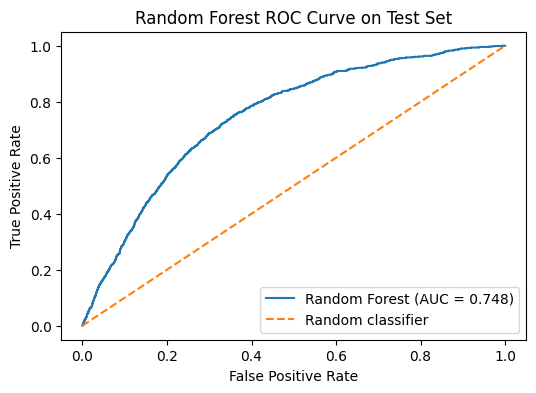

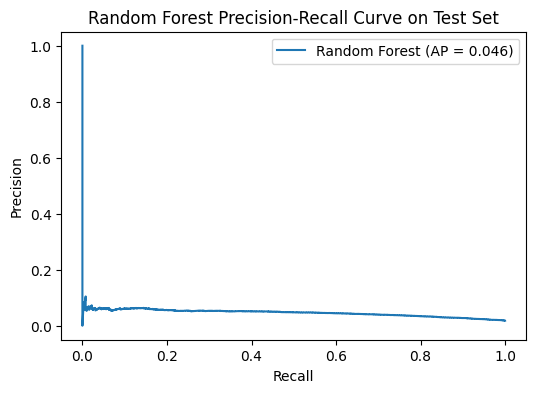

In [35]:
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_final_test_pred_prob)
rf_precision_curve, rf_recall_curve, _ = precision_recall_curve(y_test, rf_final_test_pred_prob)

plt.figure(figsize=(6, 4))
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {rf_final_test_results['roc_auc']:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve on Test Set")
plt.legend()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(
    rf_recall_curve,
    rf_precision_curve,
    label=f"Random Forest (AP = {rf_final_test_results['pr_auc']:.3f})"
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Random Forest Precision-Recall Curve on Test Set")
plt.legend()
plt.show()

The ROC curve summarizes the Random Forest model's ranking performance across all possible classification thresholds. A model with stronger ranking ability should have a ROC curve closer to the upper-left corner.

The precision-recall curve is especially important in this project because serious delinquency is rare. When the positive class is highly imbalanced, PR-AUC provides a more sensitive view of how well the model identifies delinquent loans while controlling false positives.


#### Random Forest Feature Importance

Random Forest provides feature importance measures based on how much each feature reduces impurity across the ensemble of decision trees. These importance scores help identify which origination characteristics contribute most to the model's predictions.

The most important variables should be interpreted as predictive signals rather than causal effects. In this mortgage delinquency setting, I expect borrower credit quality, leverage, debt burden, loan pricing, and loan purpose to be important predictors. These variables are closely related to mortgage credit risk because they capture the borrower's repayment capacity, the degree of collateral leverage, and the risk profile of the loan at origination.


In [36]:
rf_preprocessor = rf_final_pipeline.named_steps["preprocessor"]
rf_classifier = rf_final_pipeline.named_steps["classifier"]

rf_feature_names = rf_preprocessor.get_feature_names_out()
rf_feature_importances = rf_classifier.feature_importances_

rf_feature_importance_df = pd.DataFrame({
    "feature": rf_feature_names,
    "importance": rf_feature_importances
}).sort_values(
    by="importance",
    ascending=False
).reset_index(drop=True)

rf_feature_importance_df.head(20)

,feature,importance
0,num__credit_score,0.296686
1,num__original_interest_rate,0.166754
2,num__original_dti,0.144144
3,num__original_ltv,0.057757
4,num__original_cltv,0.056278
5,num__original_upb,0.054056
6,num__number_of_borrowers,0.035194
7,num__mortgage_insurance_percent,0.024243
8,num__original_loan_term,0.023143
9,cat__channel_R,0.011922


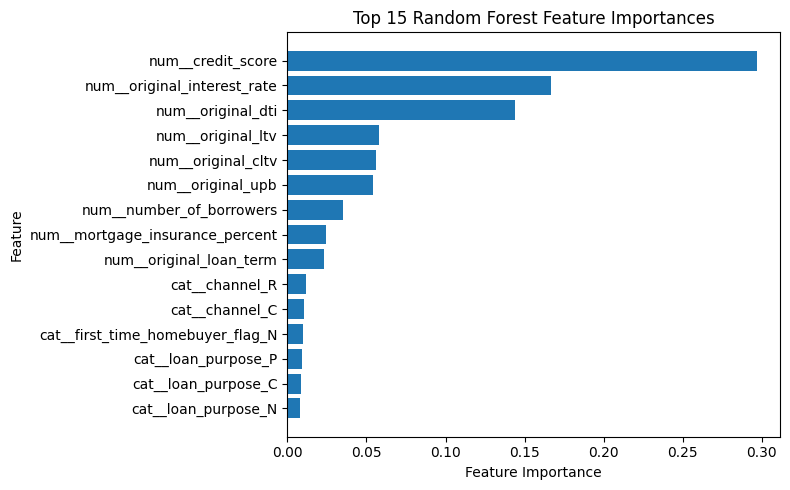

In [37]:
rf_top_feature_importance_df = rf_feature_importance_df.head(15).copy()

plt.figure(figsize=(8, 5))
plt.barh(
    rf_top_feature_importance_df["feature"][::-1],
    rf_top_feature_importance_df["importance"][::-1]
)
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Feature Importances")
plt.tight_layout()
plt.show()

The feature importance results show that credit score is the most important predictor in the Random Forest model, followed by original interest rate, original DTI, original LTV, original CLTV, and original UPB. This ranking is consistent with mortgage credit risk intuition. Credit score captures borrower credit quality, DTI reflects repayment burden, and LTV/CLTV measure leverage relative to property value. A higher original interest rate may also reflect higher borrower risk at origination.

However, these Random Forest feature importances should be interpreted as predictive importance rather than causal effects. Since the importance values are impurity-based, they may also be affected by feature scale, feature cardinality, and correlations among related variables such as LTV and CLTV.


In [38]:
rf_final_summary_for_comparison = rf_final_test_results_df.copy()

rf_final_summary_for_comparison["selected_by"] = "Validation F1"
rf_final_summary_for_comparison["n_estimators"] = rf_best_n_estimators
rf_final_summary_for_comparison["max_depth"] = "None" if rf_best_max_depth is None else rf_best_max_depth
rf_final_summary_for_comparison["min_samples_leaf"] = rf_best_min_samples_leaf
rf_final_summary_for_comparison["max_features"] = rf_best_max_features

rf_final_summary_for_comparison

,model,threshold,roc_auc,pr_auc,accuracy,precision,recall,f1,selected_by,n_estimators,max_depth,min_samples_leaf,max_features
0,Final Random Forest - Test,0.60658,0.747519,0.045829,0.78382,0.046546,0.557629,0.08592,Validation F1,200,None,100,sqrt


#### Random Forest Summary

Overall, the Random Forest model provides a nonlinear tree-based benchmark for predicting serious mortgage delinquency. Compared with linear models, Random Forest can capture nonlinear relationships and feature interactions among borrower characteristics, loan terms, and categorical origination variables. To address the rare-event nature of the target variable, I use class-balanced weights and select the classification threshold based on validation F1-score.

The final Random Forest model is evaluated on the held-out 2022 test set. Its performance can be compared with Logistic Regression, Linear SVM, MLP, and XGBoost in the main results section. In addition to predictive performance, the Random Forest feature importance results provide useful interpretation of which origination variables are most influential for delinquency prediction.


### Linear SVM


**Practice goal.**

I include a Linear Support Vector Machine (Linear SVM) as a large-margin linear classification benchmark for predicting serious mortgage delinquency.

Linear SVM attempts to separate delinquent and non-delinquent loans by maximizing the margin between the two classes. Compared with Logistic Regression, Linear SVM focuses on margin-based classification rather than directly estimating probabilities.

This approach is appropriate for my mortgage delinquency prediction problem because the dataset contains high-dimensional loan-level features and a highly imbalanced binary target variable. Since serious delinquency is a relatively rare event, I use `class_weight="balanced"` to increase the penalty for misclassifying delinquent loans.

I also standardize numerical variables because SVM models are sensitive to feature scale. The final model performance is evaluated using ROC-AUC, PR-AUC, precision, recall, and F1-score.


In [39]:
svm_class_balance_summary = pd.DataFrame({
    "dataset": ["train", "validation", "test"],
    "n_observations": [len(y_train), len(y_valid), len(y_test)],
    "n_positive": [int(y_train.sum()), int(y_valid.sum()), int(y_test.sum())],
    "n_negative": [
        int(len(y_train) - y_train.sum()),
        int(len(y_valid) - y_valid.sum()),
        int(len(y_test) - y_test.sum())
    ],
    "positive_rate": [y_train.mean(), y_valid.mean(), y_test.mean()]
})

svm_class_balance_summary

,dataset,n_observations,n_positive,n_negative,positive_rate
0,train,150000,4421,145579,0.029473
1,validation,50000,469,49531,0.009380
2,test,50000,911,49089,0.018220


Before fitting the Linear SVM model, I first check the class distribution in the training, validation, and test sets. This is important because serious delinquency is a rare event. Therefore, accuracy alone is not sufficient for evaluating model performance. I focus on ROC-AUC, PR-AUC, precision, recall, and F1-score.


In [40]:
def svm_find_best_f1_threshold(svm_y_true, svm_score):
    """
    Select the decision-score threshold that maximizes F1-score
    on the validation set.
    """
    svm_precision, svm_recall, svm_thresholds = precision_recall_curve(
        svm_y_true,
        svm_score
    )
    
    svm_precision_for_thresholds = svm_precision[:-1]
    svm_recall_for_thresholds = svm_recall[:-1]
    
    svm_f1_scores = (
        2 * svm_precision_for_thresholds * svm_recall_for_thresholds /
        (svm_precision_for_thresholds + svm_recall_for_thresholds + 1e-12)
    )
    
    svm_best_index = np.argmax(svm_f1_scores)
    svm_best_threshold = svm_thresholds[svm_best_index]
    svm_best_f1 = svm_f1_scores[svm_best_index]
    
    return svm_best_threshold, svm_best_f1

The helper function above selects the decision-score threshold that maximizes the validation-set F1-score.

This step is important because Linear SVM produces decision scores instead of calibrated probabilities, and the default threshold of zero may not perform well for highly imbalanced classification problems. By tuning the threshold on the validation set, I aim to improve the balance between precision and recall for delinquent loan detection.


#### Baseline Linear SVM Model

I first fit a baseline Linear SVM model using balanced class weights. The model uses the shared preprocessing function with `scale=True`, which imputes missing numerical values, one-hot encodes categorical variables, and standardizes numerical features.


In [41]:
svm_baseline_pipeline = Pipeline(steps=[
    ("preprocessor", make_preprocessor(scale=True)),
    ("classifier", LinearSVC(
        C=1.0,
        class_weight="balanced",
        max_iter=10000,
        random_state=RANDOM_SEED
    ))
])

_ = svm_baseline_pipeline.fit(X_train, y_train)

In [42]:
svm_baseline_valid_score = svm_baseline_pipeline.decision_function(X_valid)

svm_baseline_best_threshold, svm_baseline_best_valid_f1 = svm_find_best_f1_threshold(
    y_valid,
    svm_baseline_valid_score
)

svm_baseline_valid_results = evaluate_model(
    name="Linear SVM baseline_validation set",
    y_true=y_valid,
    y_score=svm_baseline_valid_score,
    threshold=svm_baseline_best_threshold
)

svm_baseline_valid_results_df = pd.DataFrame([svm_baseline_valid_results])
svm_baseline_valid_results_df

,Model,ROC_AUC,PR_AUC,Precision,Recall,F1,Threshold
0,Linear SVM baseline_validation set,0.782646,0.034155,0.052244,0.166311,0.079511,0.378313


The baseline Linear SVM model achieves a validation ROC-AUC of approximately 0.783, indicating moderate ranking performance between delinquent and non-delinquent loans.

However, because mortgage delinquency is a rare event, PR-AUC remains relatively low at approximately 0.034. Using the validation-set threshold selected by maximizing F1-score, the model achieves a recall of about 16.6%, meaning that it identifies a portion of delinquent loans while maintaining limited precision.

These results suggest that Linear SVM provides reasonable linear separation ability, although predictive performance remains constrained by the class imbalance and the complexity of the delinquency prediction problem.


#### Hyperparameter Tuning

I tune the regularization parameter `C`, which controls the trade-off between maximizing the margin and penalizing classification errors. Smaller values of `C` apply stronger regularization, while larger values allow the model to fit the training data more closely.

The candidate values are evaluated on the validation set, and the final specification is selected based on validation F1-score.


In [43]:
svm_tuning_results = []

svm_c_values = [0.001, 0.01, 0.1, 1.0, 10.0]

for svm_c in svm_c_values:
    
    svm_tune_pipeline = Pipeline(steps=[
        ("preprocessor", make_preprocessor(scale=True)),
        ("classifier", LinearSVC(
            C=svm_c,
            class_weight="balanced",
            max_iter=10000,
            random_state=RANDOM_SEED
        ))
    ])
    
    svm_tune_pipeline.fit(X_train, y_train)
    
    svm_valid_score = svm_tune_pipeline.decision_function(X_valid)
    
    svm_best_threshold, svm_best_valid_f1 = svm_find_best_f1_threshold(
        y_valid,
        svm_valid_score
    )
    
    svm_valid_results = evaluate_model(
        name=f"Linear SVM C={svm_c}_validation set",
        y_true=y_valid,
        y_score=svm_valid_score,
        threshold=svm_best_threshold
    )
    
    svm_valid_results["C"] = svm_c
    svm_valid_results["Best_Validation_F1_Threshold"] = svm_best_threshold
    
    svm_tuning_results.append(svm_valid_results)

svm_tuning_results_df = pd.DataFrame(svm_tuning_results)
svm_tuning_results_df = svm_tuning_results_df.sort_values("F1", ascending=False)

svm_tuning_results_df

,Model,ROC_AUC,PR_AUC,Precision,Recall,F1,Threshold,C,Best_Validation_F1_Threshold
0,Linear SVM C=0.001_validation set,0.785413,0.034915,0.060832,0.121535,0.081081,0.433565,0.001,0.433565
2,Linear SVM C=0.1_validation set,0.782715,0.034224,0.052314,0.166311,0.079592,0.378319,0.100,0.378319
3,Linear SVM C=1.0_validation set,0.782646,0.034155,0.052244,0.166311,0.079511,0.378313,1.000,0.378313
4,Linear SVM C=10.0_validation set,0.782639,0.034140,0.052244,0.166311,0.079511,0.378317,10.000,0.378317
1,Linear SVM C=0.01_validation set,0.783184,0.034378,0.052139,0.166311,0.079389,0.375719,0.010,0.375719


In [44]:
svm_best_row = svm_tuning_results_df.iloc[0]

svm_best_c = svm_best_row["C"]
svm_best_threshold = svm_best_row["Best_Validation_F1_Threshold"]

svm_best_row

Model                           Linear SVM C=0.001_validation set
ROC_AUC                                                  0.785413
PR_AUC                                                   0.034915
Precision                                                0.060832
Recall                                                   0.121535
F1                                                       0.081081
Threshold                                                0.433565
C                                                           0.001
Best_Validation_F1_Threshold                             0.433565
Name: 0, dtype: object

The tuning results show how Linear SVM performance changes across different values of the regularization parameter `C`.

Smaller values of `C` apply stronger regularization and produce a wider decision margin, while larger values reduce regularization strength and allow the classifier to fit the training data more aggressively.

Among the tested values, `C = 0.001` achieves the highest validation F1-score of approximately 0.081. Therefore, I select this value for the final Linear SVM model.

The improvement from hyperparameter tuning is relatively modest, suggesting that the overall predictive limitation is driven more by the dataset imbalance and linear decision boundary assumptions than by the choice of `C`.


#### Final Linear SVM Test Evaluation

After selecting the best hyperparameter and validation-based threshold, I evaluate the final Linear SVM model on the held-out 2022 test set.

The final model achieves a test ROC-AUC of approximately 0.753 and a PR-AUC of approximately 0.054. Compared with the validation results, PR-AUC improves slightly on the test set.

Using the tuned threshold, the model achieves a recall of approximately 54.8%, indicating that it successfully identifies over half of delinquent loans. However, precision remains relatively low at approximately 4.8%, meaning that many predicted delinquent loans are false positives.

This tradeoff is common in highly imbalanced classification problems, where improving recall often comes at the expense of precision. In the mortgage risk context, higher recall may still be valuable because missing truly delinquent loans can be more costly than generating additional false alarms.


In [45]:
svm_final_pipeline = Pipeline(steps=[
    ("preprocessor", make_preprocessor(scale=True)),
    ("classifier", LinearSVC(
        C=svm_best_c,
        class_weight="balanced",
        max_iter=10000,
        random_state=RANDOM_SEED
    ))
])

_ = svm_final_pipeline.fit(X_train, y_train)

In [46]:
svm_test_score = svm_final_pipeline.decision_function(X_test)

svm_test_results = evaluate_model(
    name="Linear SVM final_test set",
    y_true=y_test,
    y_score=svm_test_score,
    threshold=svm_best_threshold
)

svm_test_results_df = pd.DataFrame([svm_test_results])
svm_test_results_df

,Model,ROC_AUC,PR_AUC,Precision,Recall,F1,Threshold
0,Linear SVM final_test set,0.75273,0.054122,0.048418,0.54775,0.088972,0.433565


In [47]:
svm_test_pred = (svm_test_score >= svm_best_threshold).astype(int)

svm_confusion_matrix = confusion_matrix(y_test, svm_test_pred)

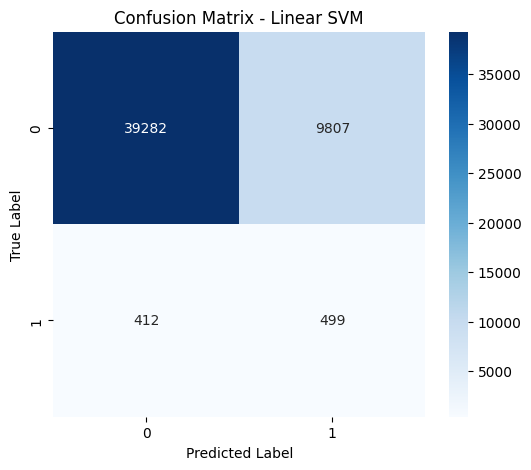

In [49]:
import seaborn as sns

plt.figure(figsize=(6, 5))

sns.heatmap(
    svm_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Linear SVM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

The confusion matrix further illustrates the tradeoff between recall and precision.

The model correctly identifies 499 delinquent loans (true positives) while missing 412 delinquent loans (false negatives). At the same time, the model generates a relatively large number of false positives, incorrectly classifying 9,807 non-delinquent loans as delinquent.

These results are consistent with the evaluation metrics above: the model prioritizes detecting delinquent loans, resulting in higher recall but lower precision.


#### ROC and Precision-Recall Curves

I further evaluate the final Linear SVM model using ROC and Precision-Recall curves. ROC-AUC measures overall ranking ability, while PR-AUC is especially informative when the positive class is rare.


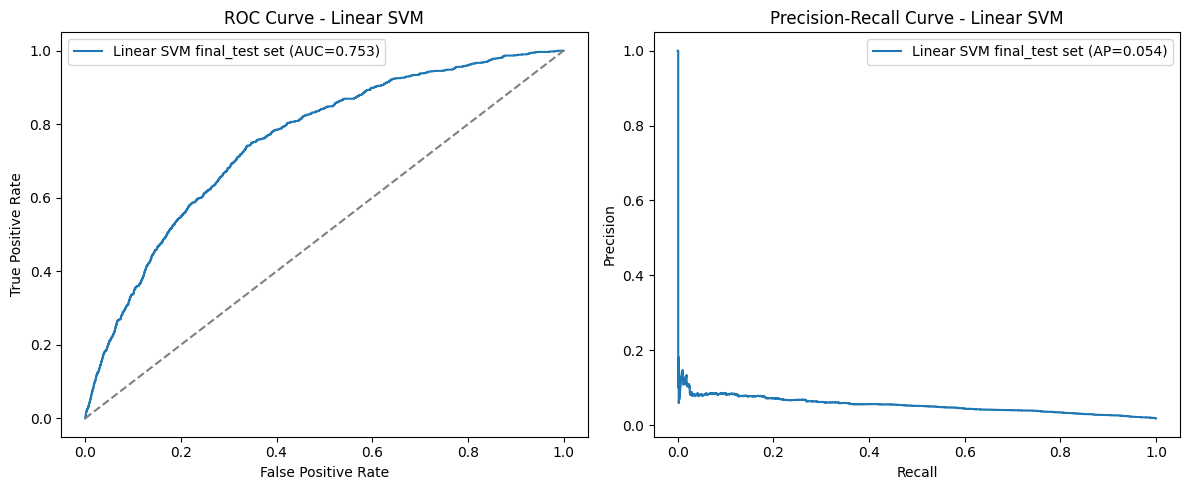

In [50]:
fig, svm_axes = plt.subplots(1, 2, figsize=(12, 5))

evaluate_model(
    name="Linear SVM final_test set",
    y_true=y_test,
    y_score=svm_test_score,
    threshold=svm_best_threshold,
    ax_roc=svm_axes[0],
    ax_pr=svm_axes[1]
)

svm_axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
svm_axes[0].set_title("ROC Curve - Linear SVM")
svm_axes[0].set_xlabel("False Positive Rate")
svm_axes[0].set_ylabel("True Positive Rate")
svm_axes[0].legend()

svm_axes[1].set_title("Precision-Recall Curve - Linear SVM")
svm_axes[1].set_xlabel("Recall")
svm_axes[1].set_ylabel("Precision")
svm_axes[1].legend()

plt.tight_layout()
plt.show()

The ROC curve shows that the Linear SVM model performs substantially better than random classification, achieving an ROC-AUC of approximately 0.753.

The Precision-Recall curve reveals the challenge of predicting rare delinquency events. Although recall can be increased, precision declines rapidly as the model attempts to identify more delinquent loans. This behavior reflects the strong class imbalance in the mortgage delinquency dataset.


#### Linear SVM Summary

Overall, the Linear SVM model provides a useful linear benchmark for predicting serious mortgage delinquency.

The model achieves moderate discriminatory performance with ROC-AUC above 0.75 and demonstrates the ability to identify a substantial portion of delinquent loans after threshold tuning. In particular, the final model achieves recall above 50% on the test set.

However, precision remains relatively low due to the severe class imbalance in the dataset. This indicates that many predicted delinquent loans are ultimately non-delinquent loans.

Compared with more flexible nonlinear models such as Random Forest, XGBoost, and MLP, Linear SVM is simpler and more interpretable, but its linear decision boundary limits predictive performance for this complex mortgage risk prediction problem.


#### Limitations

Although Linear SVM provides a strong linear benchmark, its predictive performance is still limited by the highly imbalanced nature of the mortgage delinquency dataset. The Precision-Recall AUC remains relatively low, indicating that accurately identifying rare delinquent loans is difficult.

In addition, Linear SVM assumes a linear decision boundary and may not fully capture complex nonlinear interactions among mortgage origination variables. More flexible nonlinear models such as XGBoost and Neural Networks may better capture these relationships.


### Neural Network (MLP)


**Practice goal.**

I include a multilayer perceptron (MLP) neural network as a nonlinear model in my model comparison. Mortgage delinquency risk may depend on complex and nonlinear relationships among borrower credit quality, leverage, debt burden, loan pricing, loan purpose, occupancy status, property type, and geographic characteristics. For example, the effect of a high loan-to-value ratio may be different for borrowers with high versus low credit scores, and the relationship between debt-to-income ratio and delinquency risk may not be purely linear. Compared with logistic regression and linear SVM, an MLP can learn nonlinear patterns through hidden layers without requiring me to manually specify interaction terms. This provides another perspective for predicting serious delinquency risk within the broader model comparison.

**Why appropriate here.**

An MLP is suitable for this project because the Freddie Mac mortgage dataset is a structured loan-level dataset with both numerical and categorical origination features. After preprocessing, numerical variables such as credit score, DTI, LTV, CLTV, interest rate, original UPB, and loan term can be standardized, while categorical variables such as loan purpose, occupancy status, property type, channel, and property state can be represented through one-hot encoding. This transformed feature matrix can be used as input to a feedforward neural network.

Since serious delinquency is a rare event in the dataset, the model also needs to account for class imbalance. Instead of evaluating the model using accuracy alone, I focus on ROC-AUC, PR-AUC, precision, recall, and F1-score. I also select the classification threshold using the validation set, so the final test performance reflects a threshold chosen without using future test information.

Compared with tree-based models such as Random Forest and XGBoost, the MLP is less directly interpretable, but it offers a flexible nonlinear benchmark. Its inclusion helps me examine whether a neural-network-based classifier can improve risk ranking or delinquency classification beyond linear models and ensemble tree methods.

Before fitting the MLP model, I first check the class distribution in the training, validation, and test sets. This step is important because serious delinquency is expected to be a rare event. If the positive class is very small, accuracy alone can be misleading, and the model may predict most loans as non-delinquent. Therefore, the later evaluation will focus on ROC-AUC, PR-AUC, precision, recall, and F1-score.


In [51]:
# MLP section: check class distribution
mlp_class_balance_summary = pd.DataFrame({
    "dataset": ["train", "validation", "test"],
    "n_observations": [len(y_train), len(y_valid), len(y_test)],
    "n_positive": [int(y_train.sum()), int(y_valid.sum()), int(y_test.sum())],
    "n_negative": [
        int(len(y_train) - y_train.sum()),
        int(len(y_valid) - y_valid.sum()),
        int(len(y_test) - y_test.sum())
    ],
    "positive_rate": [y_train.mean(), y_valid.mean(), y_test.mean()]
})

mlp_class_balance_summary

,dataset,n_observations,n_positive,n_negative,positive_rate
0,train,150000,4421,145579,0.029473
1,validation,50000,469,49531,0.009380
2,test,50000,911,49089,0.018220


The following helper functions are used only for the MLP section. To avoid overwriting variables or functions from the other model sections, all function and variable names in this section use the `mlp_` prefix.

The first helper function performs simple random oversampling of the positive class in the training set. I only apply oversampling to the training data, while the validation and test sets remain unchanged. This avoids changing the real class distribution used for model selection and final evaluation.

The second helper function selects the probability threshold that maximizes the validation-set F1-score. This is useful because the default threshold of 0.5 may not be appropriate for an imbalanced classification problem. The third helper function reports both threshold-free metrics, such as ROC-AUC and PR-AUC, and threshold-based metrics, such as precision, recall, and F1-score.


In [52]:
def mlp_oversample_minority_class(X_data, y_data, target_positive_rate=0.20, random_state=RANDOM_SEED):
    """
    Oversample the minority class in the training data.

    The validation and test sets should not be resampled. This function is only
    intended for the MLP training set.
    """
    mlp_rng = np.random.default_rng(random_state)

    mlp_X_reset = X_data.reset_index(drop=True)
    mlp_y_reset = y_data.reset_index(drop=True)

    mlp_positive_index = mlp_y_reset[mlp_y_reset == 1].index.to_numpy()
    mlp_negative_index = mlp_y_reset[mlp_y_reset == 0].index.to_numpy()

    mlp_n_negative = len(mlp_negative_index)
    mlp_n_positive_target = int(target_positive_rate / (1 - target_positive_rate) * mlp_n_negative)

    mlp_sampled_positive_index = mlp_rng.choice(
        mlp_positive_index,
        size=mlp_n_positive_target,
        replace=True
    )

    mlp_resampled_index = np.concatenate([mlp_negative_index, mlp_sampled_positive_index])
    mlp_rng.shuffle(mlp_resampled_index)

    mlp_X_resampled = mlp_X_reset.iloc[mlp_resampled_index].reset_index(drop=True)
    mlp_y_resampled = mlp_y_reset.iloc[mlp_resampled_index].reset_index(drop=True)

    return mlp_X_resampled, mlp_y_resampled


def mlp_find_best_f1_threshold(mlp_y_true, mlp_y_pred_prob):
    """
    Select the probability threshold that maximizes the F1-score
    on the validation set.
    """
    mlp_pr_precision, mlp_pr_recall, mlp_pr_thresholds = precision_recall_curve(
        mlp_y_true,
        mlp_y_pred_prob
    )

    mlp_f1_scores = (
        2 * mlp_pr_precision * mlp_pr_recall /
        (mlp_pr_precision + mlp_pr_recall + 1e-12)
    )

    mlp_best_index = np.argmax(mlp_f1_scores[:-1])
    mlp_best_threshold = mlp_pr_thresholds[mlp_best_index]
    mlp_best_f1 = mlp_f1_scores[mlp_best_index]

    return mlp_best_threshold, mlp_best_f1


def mlp_evaluate_binary_classifier(mlp_y_true, mlp_y_pred_prob, mlp_threshold=0.5, mlp_model_name="MLP"):
    """
    Evaluate a binary classifier using both threshold-free and threshold-based metrics.
    """
    mlp_y_pred_label = (mlp_y_pred_prob >= mlp_threshold).astype(int)

    mlp_results = {
        "model": mlp_model_name,
        "threshold": mlp_threshold,
        "roc_auc": roc_auc_score(mlp_y_true, mlp_y_pred_prob),
        "pr_auc": average_precision_score(mlp_y_true, mlp_y_pred_prob),
        "accuracy": accuracy_score(mlp_y_true, mlp_y_pred_label),
        "precision": precision_score(mlp_y_true, mlp_y_pred_label, zero_division=0),
        "recall": recall_score(mlp_y_true, mlp_y_pred_label, zero_division=0),
        "f1": f1_score(mlp_y_true, mlp_y_pred_label, zero_division=0)
    }

    return mlp_results

In [53]:
mlp_X_train_resampled, mlp_y_train_resampled = mlp_oversample_minority_class(
    X_train,
    y_train,
    target_positive_rate=0.20,
    random_state=RANDOM_SEED
)

mlp_resampled_summary = pd.DataFrame({
    "dataset": ["original training set", "MLP resampled training set"],
    "n_observations": [len(y_train), len(mlp_y_train_resampled)],
    "n_positive": [int(y_train.sum()), int(mlp_y_train_resampled.sum())],
    "n_negative": [
        int(len(y_train) - y_train.sum()),
        int(len(mlp_y_train_resampled) - mlp_y_train_resampled.sum())
    ],
    "positive_rate": [y_train.mean(), mlp_y_train_resampled.mean()]
})

mlp_resampled_summary

,dataset,n_observations,n_positive,n_negative,positive_rate
0,original training set,150000,4421,145579,0.029473
1,MLP resampled training set,181973,36394,145579,0.199997


#### Baseline MLP Model

I first fit a baseline MLP model with one hidden layer containing 32 neurons. This model is intentionally simple and serves as the neural-network benchmark before testing a more flexible architecture. The model uses the shared preprocessing function with `scale=True`, because neural networks are sensitive to the scale of numerical variables. The numerical variables are standardized, while categorical variables are one-hot encoded.

The model is trained on the oversampled training set created above, where the positive class represents approximately 20% of the resampled data. The validation set is not resampled and is used only to evaluate model performance and select the probability threshold that maximizes the validation F1-score.


In [54]:
mlp_baseline_pipeline = Pipeline(steps=[
    ("preprocessor", make_preprocessor(scale=True)),
    ("classifier", MLPClassifier(
        hidden_layer_sizes=(32,),
        activation="relu",
        solver="adam",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.10,
        n_iter_no_change=10,
        random_state=RANDOM_SEED
    ))
])

mlp_baseline_pipeline.fit(mlp_X_train_resampled, mlp_y_train_resampled)

  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret 

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['credit_score',
                                                   'mortgage_insurance_percent',
                                                   'number_of_units',
                                                   'original_cltv',
                                                   'original_dti',
                                                   'original_upb',
                                                   'original_ltv',
                                                   'original_interest_rate',
                                                   'original_loan_term',
                                                   'number_of_borrowe...
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['first_time_homebuyer_flag',
                                                   'occupancy_status',
                                                   'channel',
                                                   'amortization_type',
                                                   'property_state',
                                                   'property_type',
                                                   'loan_purpose'])])),
                ('classifier',
                 MLPClassifier(alpha=0.001, early_stopping=True,
                               hidden_layer_sizes=(32,), max_iter=300,
                               random_state=42))])

In [55]:
mlp_baseline_valid_pred_prob = mlp_baseline_pipeline.predict_proba(X_valid)[:, 1]

mlp_baseline_best_threshold, mlp_baseline_best_valid_f1 = mlp_find_best_f1_threshold(
    y_valid,
    mlp_baseline_valid_pred_prob
)

print("Baseline MLP best validation threshold:", mlp_baseline_best_threshold)
print("Baseline MLP best validation F1:", mlp_baseline_best_valid_f1)

mlp_baseline_valid_results = mlp_evaluate_binary_classifier(
    y_valid,
    mlp_baseline_valid_pred_prob,
    mlp_threshold=mlp_baseline_best_threshold,
    mlp_model_name="Baseline MLP"
)

mlp_baseline_valid_results_df = pd.DataFrame([mlp_baseline_valid_results])
mlp_baseline_valid_results_df

Baseline MLP best validation threshold: 0.35106316456946723
Baseline MLP best validation F1: 0.05844748858413829


  ret = a @ b
  ret = a @ b
  ret = a @ b


,model,threshold,roc_auc,pr_auc,accuracy,precision,recall,f1
0,Baseline MLP,0.351063,0.702124,0.022509,0.95876,0.037188,0.136461,0.058447


The baseline MLP achieved a validation ROC-AUC of 0.7021 and a PR-AUC of 0.0225. Since the validation positive rate is only about 0.94%, the PR-AUC is expected to be much lower than the ROC-AUC. After selecting the probability threshold that maximizes the validation F1-score, the baseline MLP used a threshold of 0.3511 and achieved a validation F1-score of 0.0584.

At this threshold, the model achieved relatively high overall accuracy, but its precision was only 0.0372 and its recall was 0.1365. This means that the baseline MLP was able to identify some seriously delinquent loans, but many loans predicted as high-risk were not actually delinquent. This trade-off is common in rare-event credit risk prediction and motivates testing a more flexible MLP architecture.


#### Tuned MLP Model

After fitting the baseline MLP, I test a slightly more flexible neural network architecture with two hidden layers. The tuned MLP uses 64 neurons in the first hidden layer and 32 neurons in the second hidden layer. This structure allows the model to capture more complex nonlinear relationships among the origination features while still keeping the network relatively small.

I also slightly reduce the regularization strength from `alpha = 0.001` to `alpha = 0.0005`. The purpose is to allow the model more flexibility than the baseline specification. As before, the model is trained on the oversampled training set, while the validation set remains unchanged and is used for threshold selection.


In [56]:
mlp_tuned_pipeline = Pipeline(steps=[
    ("preprocessor", make_preprocessor(scale=True)),
    ("classifier", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=0.0005,
        learning_rate_init=0.001,
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.10,
        n_iter_no_change=10,
        random_state=RANDOM_SEED
    ))
])

mlp_tuned_pipeline.fit(mlp_X_train_resampled, mlp_y_train_resampled)

  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret 

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['credit_score',
                                                   'mortgage_insurance_percent',
                                                   'number_of_units',
                                                   'original_cltv',
                                                   'original_dti',
                                                   'original_upb',
                                                   'original_ltv',
                                                   'original_interest_rate',
                                                   'original_loan_term',
                                                   'number_of_borrowe...
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['first_time_homebuyer_flag',
                                                   'occupancy_status',
                                                   'channel',
                                                   'amortization_type',
                                                   'property_state',
                                                   'property_type',
                                                   'loan_purpose'])])),
                ('classifier',
                 MLPClassifier(alpha=0.0005, early_stopping=True,
                               hidden_layer_sizes=(64, 32), max_iter=300,
                               random_state=42))])

In [45]:
mlp_tuned_valid_pred_prob = mlp_tuned_pipeline.predict_proba(X_valid)[:, 1]

mlp_tuned_best_threshold, mlp_tuned_best_valid_f1 = mlp_find_best_f1_threshold(
    y_valid,
    mlp_tuned_valid_pred_prob
)

print("Tuned MLP best validation threshold:", mlp_tuned_best_threshold)
print("Tuned MLP best validation F1:", mlp_tuned_best_valid_f1)

mlp_tuned_valid_results = mlp_evaluate_binary_classifier(
    y_valid,
    mlp_tuned_valid_pred_prob,
    mlp_threshold=mlp_tuned_best_threshold,
    mlp_model_name="Tuned MLP"
)

mlp_tuned_valid_results_df = pd.DataFrame([mlp_tuned_valid_results])
mlp_tuned_valid_results_df

Tuned MLP best validation threshold: 0.17211303330651861
Tuned MLP best validation F1: 0.045163718479327215


,model,threshold,roc_auc,pr_auc,accuracy,precision,recall,f1
0,Tuned MLP,0.172113,0.677885,0.018176,0.89852,0.024768,0.255864,0.045164


The tuned MLP achieved a validation ROC-AUC of 0.6779 and a PR-AUC of 0.0182. After threshold tuning, the selected validation threshold was 0.1721, which produced a validation F1-score of 0.0452. Compared with the baseline MLP, the tuned model achieved higher recall but lower precision, lower F1-score, lower ROC-AUC, and lower PR-AUC.

This suggests that the more flexible two-layer MLP did not improve validation performance. One possible explanation is that the larger network may be less stable in this rare-event setting, especially after oversampling the minority class. Since the baseline MLP performs better on the validation set by F1-score and also has stronger threshold-free metrics, I select the baseline MLP as the final neural network specification.


#### MLP Hyperparameter Tuning

The baseline and initial tuned MLP models show that the neural network can capture some delinquency risk patterns, but the validation performance is sensitive to model architecture and class imbalance treatment. To make the MLP comparison more systematic, I further tune several key hyperparameters.

In this tuning step, I vary the hidden layer structure, the L2 regularization strength `alpha`, the initial learning rate, and the oversampling positive rate used in the training set. For each specification, the model is trained on the resampled training set and evaluated on the original validation set. The final MLP specification is selected based on validation F1-score after threshold tuning, while ROC-AUC and PR-AUC are also reported as threshold-free performance measures.


In [46]:
mlp_tuning_results = []

mlp_hidden_layer_options = [
    (16,),
    (32,),
    (64,),
    (32, 16)
]

mlp_alpha_options = [0.001]

mlp_learning_rate_options = [0.001]

mlp_oversampling_rate_options = [0.10, 0.20, 0.30]

for mlp_target_positive_rate in mlp_oversampling_rate_options:
    mlp_X_train_tune, mlp_y_train_tune = mlp_oversample_minority_class(
        X_train,
        y_train,
        target_positive_rate=mlp_target_positive_rate,
        random_state=RANDOM_SEED
    )

    for mlp_hidden_layers in mlp_hidden_layer_options:
        for mlp_alpha_value in mlp_alpha_options:
            for mlp_learning_rate_value in mlp_learning_rate_options:

                mlp_tune_pipeline = Pipeline(steps=[
                    ("preprocessor", make_preprocessor(scale=True)),
                    ("classifier", MLPClassifier(
                        hidden_layer_sizes=mlp_hidden_layers,
                        activation="relu",
                        solver="adam",
                        alpha=mlp_alpha_value,
                        learning_rate_init=mlp_learning_rate_value,
                        max_iter=200,
                        early_stopping=True,
                        validation_fraction=0.10,
                        n_iter_no_change=8,
                        random_state=RANDOM_SEED
                    ))
                ])

                mlp_tune_pipeline.fit(mlp_X_train_tune, mlp_y_train_tune)

                print("Finished:", mlp_hidden_layers, "alpha =", mlp_alpha_value, "lr =", mlp_learning_rate_value, "oversampling =", mlp_target_positive_rate)

                mlp_tune_valid_pred_prob = mlp_tune_pipeline.predict_proba(X_valid)[:, 1]

                mlp_tune_best_threshold, mlp_tune_best_valid_f1 = mlp_find_best_f1_threshold(
                    y_valid,
                    mlp_tune_valid_pred_prob
                )

                mlp_tune_valid_metrics = mlp_evaluate_binary_classifier(
                    y_valid,
                    mlp_tune_valid_pred_prob,
                    mlp_threshold=mlp_tune_best_threshold,
                    mlp_model_name="MLP tuning"
                )

                mlp_tune_valid_metrics["hidden_layer_sizes"] = str(mlp_hidden_layers)
                mlp_tune_valid_metrics["alpha"] = mlp_alpha_value
                mlp_tune_valid_metrics["learning_rate_init"] = mlp_learning_rate_value
                mlp_tune_valid_metrics["oversampling_positive_rate"] = mlp_target_positive_rate

                mlp_tuning_results.append(mlp_tune_valid_metrics)

mlp_tuning_results_df = pd.DataFrame(mlp_tuning_results)

mlp_tuning_results_df = mlp_tuning_results_df.sort_values(
    by="f1",
    ascending=False
).reset_index(drop=True)

mlp_tuning_results_df.head(10)

Finished: (16,) alpha = 0.001 lr = 0.001 oversampling = 0.1
Finished: (32,) alpha = 0.001 lr = 0.001 oversampling = 0.1
Finished: (64,) alpha = 0.001 lr = 0.001 oversampling = 0.1
Finished: (32, 16) alpha = 0.001 lr = 0.001 oversampling = 0.1
Finished: (16,) alpha = 0.001 lr = 0.001 oversampling = 0.2
Finished: (32,) alpha = 0.001 lr = 0.001 oversampling = 0.2
Finished: (64,) alpha = 0.001 lr = 0.001 oversampling = 0.2
Finished: (32, 16) alpha = 0.001 lr = 0.001 oversampling = 0.2
Finished: (16,) alpha = 0.001 lr = 0.001 oversampling = 0.3
Finished: (32,) alpha = 0.001 lr = 0.001 oversampling = 0.3
Finished: (64,) alpha = 0.001 lr = 0.001 oversampling = 0.3
Finished: (32, 16) alpha = 0.001 lr = 0.001 oversampling = 0.3


,model,threshold,roc_auc,pr_auc,accuracy,precision,recall,f1,hidden_layer_sizes,alpha,learning_rate_init,oversampling_positive_rate
0,MLP tuning,0.186449,0.773456,0.030201,0.95142,0.043336,0.198294,0.071128,"(16,)",0.001,0.001,0.1
1,MLP tuning,0.416250,0.724280,0.025419,0.97120,0.048372,0.110874,0.067358,"(32,)",0.001,0.001,0.2
2,MLP tuning,0.364466,0.753491,0.026950,0.97142,0.048023,0.108742,0.066623,"(16,)",0.001,0.001,0.2
3,MLP tuning,0.173775,0.762277,0.027510,0.93280,0.036847,0.245203,0.064067,"(32,)",0.001,0.001,0.1
4,MLP tuning,0.422728,0.752553,0.025653,0.92432,0.035584,0.270789,0.062902,"(16,)",0.001,0.001,0.3
5,MLP tuning,0.685405,0.684781,0.021667,0.97534,0.048463,0.087420,0.062357,"(64,)",0.001,0.001,0.3
6,MLP tuning,0.125504,0.734842,0.024157,0.92070,0.034115,0.272921,0.060649,"(32, 16)",0.001,0.001,0.1
7,MLP tuning,0.379696,0.728506,0.022909,0.90974,0.031076,0.285714,0.056055,"(32,)",0.001,0.001,0.3
8,MLP tuning,0.360146,0.695076,0.021527,0.95188,0.032352,0.142857,0.052756,"(64,)",0.001,0.001,0.2
9,MLP tuning,0.360744,0.693633,0.020789,0.95034,0.031628,0.144989,0.051928,"(32, 16)",0.001,0.001,0.2


Because the MLP model is relatively computationally expensive on this loan-level dataset, I used an ultra-light hyperparameter tuning strategy instead of a full grid search. The training set contains 150,000 original observations, and after oversampling and one-hot encoding, each MLP specification requires nontrivial computation time. A more exhaustive tuning approach would test a larger grid of hidden layer structures, regularization strengths, learning rates, and class imbalance treatments, possibly using cross-validation or randomized search. However, given the computational constraint and the size of the dataset, I use the validation set to compare a smaller set of reasonable MLP specifications.

The ultra-light tuning results show that the best validation performance is achieved by a relatively simple network with one hidden layer of 16 neurons, `alpha = 0.001`, `learning_rate_init = 0.001`, and an oversampled training positive rate of 0.10. This model achieves a validation ROC-AUC of 0.7735, PR-AUC of 0.0320, and F1-score of 0.0711. Compared with the earlier baseline MLP, this tuned specification improves validation ROC-AUC, PR-AUC, and F1-score. Therefore, I select this tuned specification as the final MLP model for test-set evaluation.


#### Final Tuned MLP Test Evaluation

Based on the validation tuning results, I refit the final MLP model using the best selected hyperparameter specification. The selected model uses one hidden layer with 16 neurons, L2 regularization strength `alpha = 0.001`, initial learning rate `0.001`, and an oversampled training positive rate of 0.10. The probability threshold is selected from the validation set and is then applied to the 2022 test set for final out-of-sample evaluation.


In [57]:
mlp_final_X_train_resampled, mlp_final_y_train_resampled = mlp_oversample_minority_class(
    X_train,
    y_train,
    target_positive_rate=0.10,
    random_state=RANDOM_SEED
)

mlp_final_tuned_pipeline = Pipeline(steps=[
    ("preprocessor", make_preprocessor(scale=True)),
    ("classifier", MLPClassifier(
        hidden_layer_sizes=(16,),
        activation="relu",
        solver="adam",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=200,
        early_stopping=True,
        validation_fraction=0.10,
        n_iter_no_change=8,
        random_state=RANDOM_SEED
    ))
])

mlp_final_tuned_pipeline.fit(
    mlp_final_X_train_resampled,
    mlp_final_y_train_resampled
)

  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b
  ret = a @ b


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['credit_score',
                                                   'mortgage_insurance_percent',
                                                   'number_of_units',
                                                   'original_cltv',
                                                   'original_dti',
                                                   'original_upb',
                                                   'original_ltv',
                                                   'original_interest_rate',
                                                   'original_loan_term',
                                                   'number_of_borrowe...
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['first_time_homebuyer_flag',
                                                   'occupancy_status',
                                                   'channel',
                                                   'amortization_type',
                                                   'property_state',
                                                   'property_type',
                                                   'loan_purpose'])])),
                ('classifier',
                 MLPClassifier(alpha=0.001, early_stopping=True,
                               hidden_layer_sizes=(16,), n_iter_no_change=8,
                               random_state=42))])

In [58]:
mlp_final_valid_pred_prob = mlp_final_tuned_pipeline.predict_proba(X_valid)[:, 1]

mlp_final_best_threshold, mlp_final_best_valid_f1 = mlp_find_best_f1_threshold(
    y_valid,
    mlp_final_valid_pred_prob
)

print("Final tuned MLP validation threshold:", mlp_final_best_threshold)
print("Final tuned MLP validation F1:", mlp_final_best_valid_f1)

mlp_final_valid_results = mlp_evaluate_binary_classifier(
    y_valid,
    mlp_final_valid_pred_prob,
    mlp_threshold=mlp_final_best_threshold,
    mlp_model_name="Final Tuned MLP Validation"
)

mlp_final_valid_results_df = pd.DataFrame([mlp_final_valid_results])
mlp_final_valid_results_df

Final tuned MLP validation threshold: 0.1864488694181333
Final tuned MLP validation F1: 0.07112810707427542


  ret = a @ b
  ret = a @ b
  ret = a @ b


,model,threshold,roc_auc,pr_auc,accuracy,precision,recall,f1
0,Final Tuned MLP Validation,0.186449,0.773456,0.030201,0.95142,0.043336,0.198294,0.071128


In [59]:
mlp_final_test_pred_prob = mlp_final_tuned_pipeline.predict_proba(X_test)[:, 1]

mlp_final_test_results = mlp_evaluate_binary_classifier(
    y_test,
    mlp_final_test_pred_prob,
    mlp_threshold=mlp_final_best_threshold,
    mlp_model_name="Final Tuned MLP Test"
)

mlp_final_test_results_df = pd.DataFrame([mlp_final_test_results])
mlp_final_test_results_df

  ret = a @ b
  ret = a @ b
  ret = a @ b


,model,threshold,roc_auc,pr_auc,accuracy,precision,recall,f1
0,Final Tuned MLP Test,0.186449,0.730181,0.045694,0.74172,0.040432,0.579583,0.075591


In [60]:
mlp_final_test_pred_label = (
    mlp_final_test_pred_prob >= mlp_final_best_threshold
).astype(int)

print("Final Tuned MLP Test Confusion Matrix:")
print(confusion_matrix(y_test, mlp_final_test_pred_label))

print("\nFinal Tuned MLP Test Classification Report:")
print(classification_report(y_test, mlp_final_test_pred_label, zero_division=0))

Final Tuned MLP Test Confusion Matrix:
[[36558 12531]
 [  383   528]]

Final Tuned MLP Test Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.74      0.85     49089
           1       0.04      0.58      0.08       911

    accuracy                           0.74     50000
   macro avg       0.52      0.66      0.46     50000
weighted avg       0.97      0.74      0.84     50000



The final tuned MLP achieved a validation ROC-AUC of 0.7735 and a PR-AUC of 0.0302. After selecting the probability threshold that maximized validation F1-score, the selected threshold was 0.1864 and the validation F1-score was 0.0711. This selected model improved over the earlier baseline MLP in terms of validation ROC-AUC, PR-AUC, and F1-score.

On the 2022 test set, the final tuned MLP achieved a ROC-AUC of 0.7302 and a PR-AUC of 0.0457. Using the validation-selected threshold, the model achieved an accuracy of 0.7417, precision of 0.0404, recall of 0.5796, and F1-score of 0.0756. The confusion matrix shows that the model correctly identified 528 out of 911 seriously delinquent loans, but it also classified 12,531 non-delinquent loans as high risk. This indicates that the MLP is able to detect a substantial share of future serious delinquency cases, but its precision remains low due to the rare-event nature of the target variable.

Overall, the final tuned MLP is useful as a high-recall risk screening model, but it may not be suitable as a standalone decision model without further calibration or additional business rules to reduce false positives.


#### ROC Curve and Precision-Recall Curve

I further evaluate the final tuned MLP model using the ROC curve and the precision-recall curve on the test set. The ROC curve measures the model's ability to rank delinquent loans above non-delinquent loans across different thresholds. The precision-recall curve is especially important in this project because serious delinquency is a rare event, so precision and recall provide a more informative view of model performance than accuracy alone.


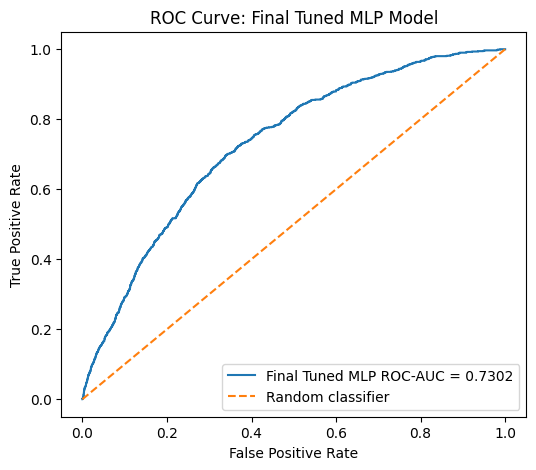

In [61]:
mlp_final_roc_fpr, mlp_final_roc_tpr, mlp_final_roc_thresholds = roc_curve(
    y_test,
    mlp_final_test_pred_prob
)

mlp_final_test_roc_auc = roc_auc_score(
    y_test,
    mlp_final_test_pred_prob
)

plt.figure(figsize=(6, 5))
plt.plot(
    mlp_final_roc_fpr,
    mlp_final_roc_tpr,
    label=f"Final Tuned MLP ROC-AUC = {mlp_final_test_roc_auc:.4f}"
)
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Final Tuned MLP Model")
plt.legend()
plt.show()

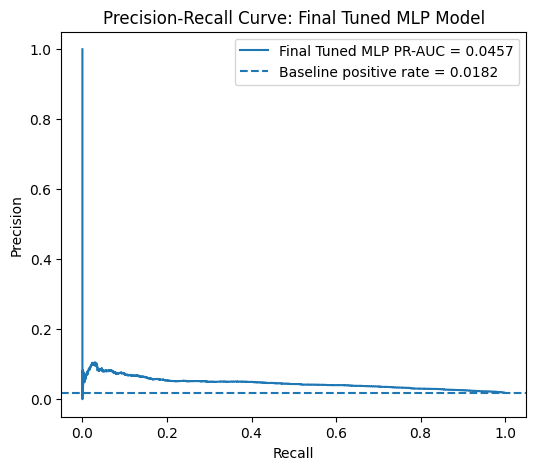

In [62]:
mlp_final_pr_precision, mlp_final_pr_recall, mlp_final_pr_thresholds = precision_recall_curve(
    y_test,
    mlp_final_test_pred_prob
)

mlp_final_test_pr_auc = average_precision_score(
    y_test,
    mlp_final_test_pred_prob
)

mlp_final_test_positive_rate = y_test.mean()

plt.figure(figsize=(6, 5))
plt.plot(
    mlp_final_pr_recall,
    mlp_final_pr_precision,
    label=f"Final Tuned MLP PR-AUC = {mlp_final_test_pr_auc:.4f}"
)
plt.axhline(
    y=mlp_final_test_positive_rate,
    linestyle="--",
    label=f"Baseline positive rate = {mlp_final_test_positive_rate:.4f}"
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve: Final Tuned MLP Model")
plt.legend()
plt.show()

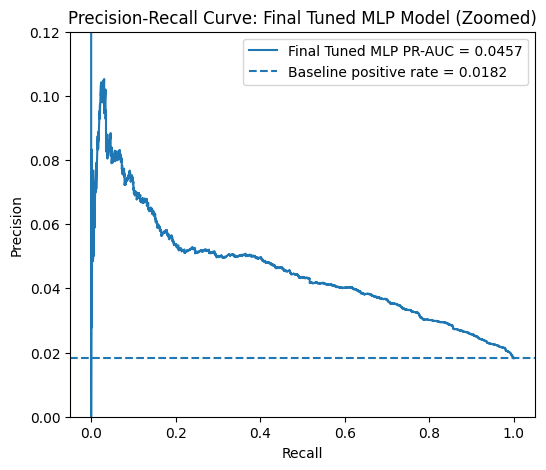

In [63]:
plt.figure(figsize=(6, 5))
plt.plot(
    mlp_final_pr_recall,
    mlp_final_pr_precision,
    label=f"Final Tuned MLP PR-AUC = {mlp_final_test_pr_auc:.4f}"
)
plt.axhline(
    y=mlp_final_test_positive_rate,
    linestyle="--",
    label=f"Baseline positive rate = {mlp_final_test_positive_rate:.4f}"
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve: Final Tuned MLP Model (Zoomed)")
plt.ylim(0, 0.12)
plt.legend()
plt.show()

The precision-recall curve shows that the final tuned MLP achieves a PR-AUC of 0.0457, which is higher than the test-set baseline positive rate of 0.0182. This indicates that the model performs better than random screening in identifying seriously delinquent loans. However, because serious delinquency is a rare event, the overall precision remains low.

The zoomed-in precision-recall curve makes this pattern clearer. Most precision values are concentrated below 0.12, which is why the original PR curve appears compressed near the bottom of the plot. As recall increases, precision gradually declines toward the baseline positive rate. This confirms that the final tuned MLP is more useful as a high-recall risk screening model than as a high-precision standalone classifier.


#### Final MLP Summary

Overall, the MLP model provides a useful nonlinear benchmark for predicting serious delinquency in the Freddie Mac mortgage dataset. I first fitted a baseline MLP with one hidden layer of 32 neurons. Then, I tested a more flexible two-layer MLP and conducted a small-scale hyperparameter tuning process over hidden layer size, oversampling positive rate, regularization strength, and learning rate. Because MLP training is computationally expensive on this loan-level dataset, I used a limited tuning strategy instead of a full grid search. A more exhaustive tuning approach could test a larger set of neural network architectures and class imbalance treatments, but this smaller search still allows me to compare several reasonable MLP specifications.

The final selected MLP uses one hidden layer with 16 neurons, `alpha = 0.001`, `learning_rate_init = 0.001`, and an oversampled training positive rate of 0.10. The classification threshold was selected on the validation set by maximizing F1-score. On the 2022 test set, this final tuned MLP achieved a ROC-AUC of 0.7302 and a PR-AUC of 0.0457. At the validation-selected threshold, it achieved precision of 0.0404, recall of 0.5796, and F1-score of 0.0756.

The main strength of the MLP is its relatively high recall. It correctly identifies 528 out of 911 seriously delinquent loans in the test set. However, precision remains low because serious delinquency is rare, and the model produces many false positives. Therefore, the MLP is better interpreted as a high-recall risk screening model rather than a standalone high-precision decision model. Compared with more interpretable models, the MLP is also less transparent, so its results should be considered together with the other models in the final model comparison.


In [64]:
mlp_final_summary_df = pd.DataFrame({
    "model": ["Final Tuned MLP"],
    "selected_hidden_layer_sizes": ["(16,)"],
    "alpha": [0.001],
    "learning_rate_init": [0.001],
    "oversampling_positive_rate": [0.10],
    "selected_threshold": [mlp_final_best_threshold],
    "test_roc_auc": [roc_auc_score(y_test, mlp_final_test_pred_prob)],
    "test_pr_auc": [average_precision_score(y_test, mlp_final_test_pred_prob)],
    "test_accuracy": [accuracy_score(y_test, mlp_final_test_pred_label)],
    "test_precision": [precision_score(y_test, mlp_final_test_pred_label, zero_division=0)],
    "test_recall": [recall_score(y_test, mlp_final_test_pred_label, zero_division=0)],
    "test_f1": [f1_score(y_test, mlp_final_test_pred_label, zero_division=0)]
})

mlp_final_summary_df.round(4)

,model,selected_hidden_layer_sizes,alpha,learning_rate_init,oversampling_positive_rate,selected_threshold,test_roc_auc,test_pr_auc,test_accuracy,test_precision,test_recall,test_f1
0,Final Tuned MLP,"(16,)",0.001,0.001,0.1,0.1864,0.7302,0.0457,0.7417,0.0404,0.5796,0.0756


### XGBoost

**Practice goal.**

I include XGBoost as a nonlinear boosting model in my model comparison. Mortgage delinquency risk may depend on nonlinear relationships and interactions among borrower credit quality, leverage, debt burden, loan terms, loan purpose, and geographic characteristics. For example, the risk associated with a high-LTV loan may differ depending on whether the borrower has a high or low credit score. Compared with a linear model, XGBoost can capture these nonlinear patterns without requiring me to manually specify interaction terms. In addition, XGBoost provides a boosting-based approach, where trees are built sequentially and each new tree focuses on improving the errors from previous trees. This provides another perspective for modeling serious delinquency risk within the broader model comparison.

**Why appropriate here.**

XGBoost is suitable for this project because the Freddie Mac mortgage dataset is a tabular dataset with both numerical and categorical origination features. The model can capture nonlinear relationships among variables such as credit score, DTI, LTV, interest rate, loan purpose, and property location. Since serious delinquency is a highly imbalanced outcome, I apply scale_pos_weight to give more weight to the minority delinquent class during training. XGBoost also allows me to use regularization, subsampling, and column subsampling to reduce overfitting risk. Finally, gain-based feature importance helps me interpret which origination variables contribute most to the model’s risk ranking.


#### Baseline Model

I first estimated a regularized baseline XGBoost model rather than using the fully default specification. The default XGBoost settings might not be appropriate for this imbalanced classification problem, especially because deeper trees and a higher learning rate may increase the risk of overfitting. Therefore, my baseline used a lower learning rate, shallower trees, subsampling, column subsampling, and L2 regularization to make the model more conservative. I then applied randomized hyperparameter search to examine whether further tuning could improve performance.


#### Handling Class Imbalance


The target variable is highly imbalanced because only a small proportion of loans became seriously delinquent within 24 months. In the training set, there were 4,421 positive cases and 145,579 negative cases. To address this imbalance, I used XGBoost’s `scale_pos_weight` parameter, calculated as the ratio of negative to positive cases. This gives more weight to the minority delinquent class during training and helps reduce the model’s tendency to favor the majority non-delinquent class.


In [85]:
positive = y_train.sum()
negative = len(y_train) - positive
scale_pos_weight = negative / positive

print("Positive cases:", positive)
print("Negative cases:", negative)
print("scale_pos_weight:", scale_pos_weight)

#baseline
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
xgb_baseline = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    n_estimators=500,
    learning_rate=0.03,
    max_depth=3,
    min_child_weight=10,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=5,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)
xgb_classifier = Pipeline(steps=[
    ("preprocessor", make_preprocessor(scale=False)),
    ("model", xgb_baseline)
])
xgb_classifier.fit(X_train, y_train)

Positive cases: 4421
Negative cases: 145579
scale_pos_weight: 32.92897534494458


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['credit_score',
                                                   'mortgage_insurance_percent',
                                                   'number_of_units',
                                                   'original_cltv',
                                                   'original_dti',
                                                   'original_upb',
                                                   'original_ltv',
                                                   'original_interest_rate',
                                                   'original_loan_term',
                                                   'number_of_borrowers']),
                                                 ('cat',
                                                  Pipeline(steps=...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.03,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_leaves=None,
                               min_child_weight=10, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=500, n_jobs=-1,
                               num_parallel_tree=None, random_state=42, ...))])

Therefore, I set `scale_pos_weight` to 32.93, calculated as the ratio of negative to positive cases.


#### Threshold Selection


Since the target variable is highly imbalanced, the default threshold of 0.5 may not provide the best balance between precision and recall. Therefore, I selected the threshold that maximized the F1-score on the validation set.


In [80]:
valid_prob = xgb_classifier.predict_proba(X_valid)[:, 1]

#find best threshold using validation set
precision, recall, thresholds = precision_recall_curve(y_valid, valid_prob)
f1_scores = 2 * precision * recall / (precision + recall)
best_index = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_index]
print("Best threshold:", best_threshold)
print("Best validation F1:", f1_scores[best_index])

Best threshold: 0.69401586
Best validation F1: 0.07736720554272518


Therefore, I used the validation set to select the threshold that maximized the F1-score. The best threshold was 0.6940, which produced a validation F1-score of 0.0774.


In [82]:
base_valid_perform = evaluate_model(
    name="XGBoost baseline_validation set",
    y_true=y_valid,
    y_score=valid_prob,
    threshold=best_threshold
)

base_valid_df = pd.DataFrame([base_valid_perform])
base_valid_df

,Model,ROC_AUC,PR_AUC,Precision,Recall,F1,Threshold
0,XGBoost baseline_validation set,0.775833,0.033226,0.053048,0.142857,0.077367,0.694016


For the baseline XGBoost model, the validation ROC-AUC is 0.7758, suggesting that the model has ability to rank higher-risk loans above lower-risk loans. However, the PR-AUC is only 0.0332, reflecting the difficulty of identifying serious delinquency in a highly imbalanced dataset.

Using the validation threshold that maximizes F1-score, the model achieves a precision of 0.0530 and a recall of 0.1428. This means that only about 5.3% of loans predicted as delinquent are truly delinquent, while the model captures about 14.3% of actual delinquent loans.

Overall, the baseline model provides useful ranking ability, but its classification performance is still limited, especially in terms of precision, recall, and F-1 Score.


In [83]:
#test set
test_prob = xgb_classifier.predict_proba(X_test)[:, 1]
best_test_perform = evaluate_model(
    name="XGBoost baseline_test set",
    y_true=y_test,
    y_score=test_prob,
    threshold=best_threshold
)
best_test_df = pd.DataFrame([best_test_perform])
best_test_df

,Model,ROC_AUC,PR_AUC,Precision,Recall,F1,Threshold
0,XGBoost baseline_test set,0.761602,0.056207,0.050167,0.594951,0.092531,0.694016


On the test set, the baseline XGBoost model achieves a ROC-AUC of 0.7616, suggesting that the model has ability to rank higher-risk loans above lower-risk loans. The PR-AUC is 0.0562, which remains relatively low but is expected given the highly imbalanced nature of serious delinquency.

The model achieves a precision of 0.0502 and a recall of 0.5950. This means that the model captures about 59.5% of actual delinquent loans, but only about 5% of loans predicted as delinquent are truly delinquent.


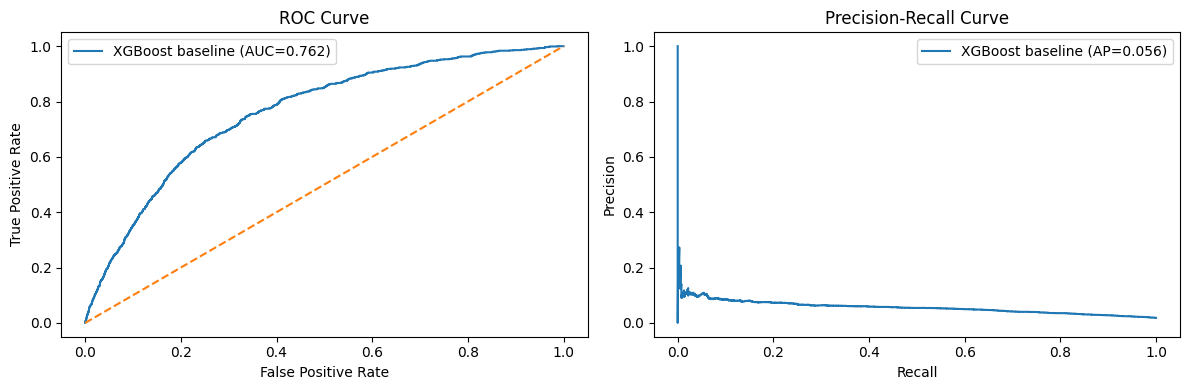

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

base_test_perform = evaluate_model(
    name="XGBoost baseline",
    y_true=y_test,
    y_score=test_prob,
    threshold=best_threshold,
    ax_roc=axes[0],
    ax_pr=axes[1]
)

axes[0].plot([0, 1], [0, 1], linestyle="--")
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.tight_layout()
plt.show()

The ROC curve indicates that the baseline XGBoost model has reasonable risk-ranking ability, with a test ROC-AUC of 0.7616. However, the precision-recall curve shows that precision remains limited, which is expected given the rarity of serious delinquency. At the validation-selected threshold, the model captures many delinquent loans but also produces many false positives.


#### Hyperparameter Tuning


For hyperparameter tuning, I used RandomizedSearchCV with 3-fold time-series cross-validation. Since serious delinquency is a highly imbalanced outcome, I used average precision, or PR-AUC, as the tuning metric instead of accuracy.

The search evaluated 15 random parameter combinations across 3 folds, resulting in 45 total model fits.


In [70]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
import numpy as np
import pandas as pd

train_sorted = train.sort_values(["vintage_year", "first_payment_date"]).copy()

X_train_search = train_sorted[feature_cols]
y_train_search = train_sorted["target"].astype(int)

xgb_for_search = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

xgb_search_pipeline = Pipeline(steps=[
    ("preprocessor", make_preprocessor(scale=False)),
    ("model", xgb_for_search)
])

param_distributions = {
    "model__n_estimators": [200, 300, 500],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.08],
    "model__max_depth": [2, 3, 4, 5],
    "model__min_child_weight": [5, 10, 20],
    "model__subsample": [0.7, 0.8, 1.0], # % of train set
    "model__colsample_bytree": [0.7, 0.8, 1.0], # % of features
    "model__gamma": [0, 0.5, 1], # split threshold
    "model__reg_lambda": [1, 5, 10], # L2
    "model__reg_alpha": [0, 0.1, 1] # L1
}

tscv = TimeSeriesSplit(n_splits=3)

search = RandomizedSearchCV(
    estimator=xgb_search_pipeline,
    param_distributions=param_distributions,
    n_iter=15,
    scoring="average_precision",       # PR-AUC, good for imbalanced data
    cv=tscv,
    random_state=42,
    n_jobs=1,
    verbose=1,
    refit=True
)

search.fit(X_train_search, y_train_search)

print("Best CV PR-AUC:", search.best_score_)
print("Best parameters:")
print(search.best_params_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best CV PR-AUC: 0.07796712233369954
Best parameters:
{'model__subsample': 0.7, 'model__reg_lambda': 5, 'model__reg_alpha': 0, 'model__n_estimators': 200, 'model__min_child_weight': 5, 'model__max_depth': 4, 'model__learning_rate': 0.05, 'model__gamma': 0, 'model__colsample_bytree': 0.7}


The best cross-validation PR-AUC was 0.0780. The selected model used 200 trees, a learning rate of 0.05, maximum tree depth of 4, min_child_weight of 5, subsample of 0.7, and colsample_bytree of 0.7, with additional regularization through gamma, reg_alpha, and reg_lambda.


In [71]:
xgb_best = search.best_estimator_

#choose threshold by validation set
valid_prob_tuned = xgb_best.predict_proba(X_valid)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_valid, valid_prob_tuned)
precision_for_thresholds = precision[:-1]
recall_for_thresholds = recall[:-1]
f1_scores = 2 * precision_for_thresholds * recall_for_thresholds / (
    precision_for_thresholds + recall_for_thresholds + 1e-9)
best_index = np.argmax(f1_scores)
best_threshold_tuned = thresholds[best_index]
print("Best threshold for tuned model:", best_threshold_tuned)
print("Best validation F1 for tuned model:", f1_scores[best_index])

Best threshold for tuned model: 0.67544466
Best validation F1 for tuned model: 0.07696307815432583


After hyperparameter tuning, I selected the classification threshold again on the validation set by maximizing the F1-score. The best threshold for the tuned model was 0.6754, producing a validation F1-score of 0.0770.


In [72]:
tuned_valid_perform = evaluate_model(
    name="XGBoost tuned_validation set",
    y_true=y_valid,
    y_score=valid_prob_tuned,
    threshold=best_threshold_tuned
)
tuned_valid_perform_df = pd.DataFrame([tuned_valid_perform])
tuned_valid_perform_df

,Model,ROC_AUC,PR_AUC,Precision,Recall,F1,Threshold
0,XGBoost tuned_validation set,0.772732,0.030965,0.050894,0.157783,0.076963,0.675445


For the tuned XGBoost model, the validation ROC-AUC is 0.7727, suggesting that the model still has some ability to rank higher-risk loans above lower-risk loans.

However, the PR-AUC is only 0.0310, reflecting the difficulty of identifying serious delinquency in a highly imbalanced setting.

Using the validation threshold that maximizes F1-score, the model achieves a precision of 0.0509 and a recall of 0.1578. This means that about 5.1% of loans predicted as delinquent are truly delinquent, while the model captures about 15.8% of actual delinquent loans. The resulting F1-score is 0.0770.


In [73]:
#test set (tuned)
test_prob_tuned = xgb_best.predict_proba(X_test)[:, 1]

tuned_test_perform = evaluate_model(
    name="XGBoost tuned_test set",
    y_true=y_test,
    y_score=test_prob_tuned,
    threshold=best_threshold_tuned
)
tuned_test_perform_df = pd.DataFrame([tuned_test_perform])
tuned_test_perform_df

,Model,ROC_AUC,PR_AUC,Precision,Recall,F1,Threshold
0,XGBoost tuned_test set,0.760938,0.055399,0.047461,0.610318,0.088072,0.675445


On the test set, the tuned XGBoost model achieves a ROC-AUC of 0.7609, suggesting that it still has reasonable ability to rank higher-risk loans above lower-risk loans.

However, the PR-AUC is only 0.0554, reflecting the difficulty of identifying serious delinquency in a highly imbalanced dataset.

Using the threshold selected from the validation set, the model achieves a precision of 0.0475 and a recall of 0.6103. This means that the model captures about 61.0% of actual delinquent loans, but only about 4.7% of loans predicted as delinquent are truly delinquent. Overall, the tuned model is useful for broad risk screening, but its precision remains limited.


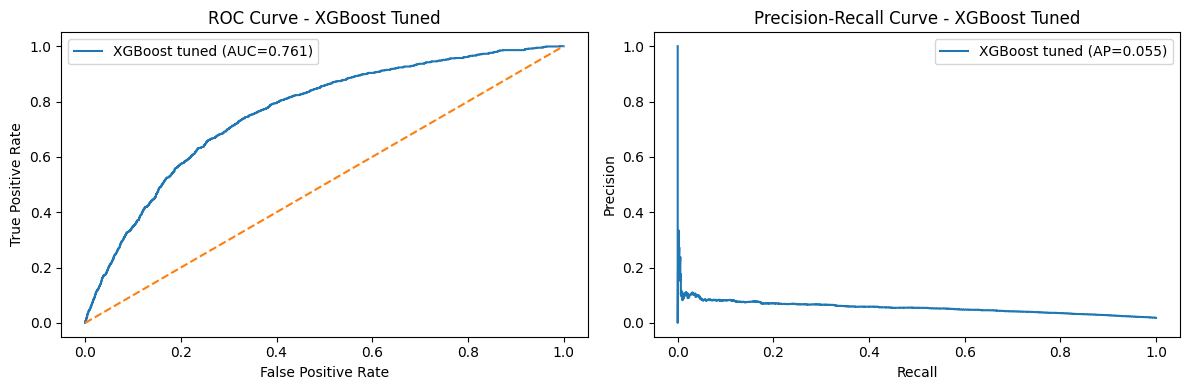

In [74]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

_ = evaluate_model(
    name="XGBoost tuned",
    y_true=y_test,
    y_score=test_prob_tuned,
    threshold=best_threshold_tuned,
    ax_roc=axes[0],
    ax_pr=axes[1]
)

axes[0].plot([0, 1], [0, 1], linestyle="--")
axes[0].set_title("ROC Curve - XGBoost Tuned")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

axes[1].set_title("Precision-Recall Curve - XGBoost Tuned")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.tight_layout()
plt.show()

#### Final Model and Test Evaluation


Since the regularized baseline XGBoost model performed similarly to or slightly better than the tuned model, I retained it as the final model. Therefore, the feature importance analysis is based on the baseline model.


#### Feature Importance and Interpretation


In [75]:
#tuned model
feature_names = xgb_classifier.named_steps["preprocessor"].get_feature_names_out()
xgb_model = xgb_classifier.named_steps["model"]

booster = xgb_model.get_booster()
gain_scores = booster.get_score(importance_type="gain")
importance = pd.DataFrame({
    "feature_index": list(gain_scores.keys()),
    "gain": list(gain_scores.values())
})
# Convert f0, f1, f2... to numeric index
importance["idx"] = importance["feature_index"].str.replace("f", "").astype(int)

# Map back to actual feature names
importance["feature"] = importance["idx"].apply(lambda i: feature_names[i])

# Clean feature names
importance["feature_clean"] = (
    importance["feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

importance = importance.sort_values("gain", ascending=False)

importance.head(15)

,feature_index,gain,idx,feature,feature_clean
0,f0,909.593506,0,num__credit_score,credit_score
4,f4,478.731415,4,num__original_dti,original_dti
7,f7,466.968933,7,num__original_interest_rate,original_interest_rate
9,f9,388.766144,9,num__number_of_borrowers,number_of_borrowers
3,f3,279.502258,3,num__original_cltv,original_cltv
17,f17,263.547607,17,cat__channel_R,channel_R
16,f16,253.407410,16,cat__channel_C,channel_C
8,f8,212.778931,8,num__original_loan_term,original_loan_term
44,f51,211.579849,51,cat__property_state_NJ,property_state_NJ
47,f54,190.529358,54,cat__property_state_NY,property_state_NY


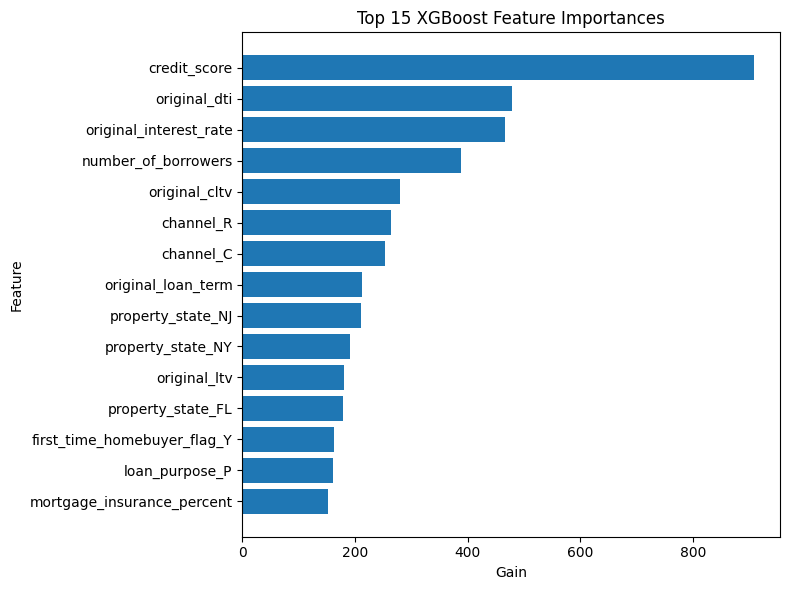

In [76]:
top_importance = importance.head(15).sort_values("gain")

plt.figure(figsize=(8, 6))
plt.barh(top_importance["feature_clean"], top_importance["gain"])
plt.title("Top 15 XGBoost Feature Importances")
plt.xlabel("Gain")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

The feature importance results are consistent with mortgage credit risk intuition. Credit score is the most important feature, followed by DTI, interest rate, number of borrowers, CLTV, and LTV. These variables capture borrower credit quality, borrowing cost, debt burden, and leverage at origination. Some categorical variables, including channel, loan purpose, and property-state indicators, also contribute to the model, suggesting that origination characteristics and geographic variation provide additional predictive information.


#### XGBoost Result Summary


In [77]:
summary_results = pd.DataFrame([
    base_valid_perform,
    base_test_perform,
    tuned_valid_perform,
    tuned_test_perform
])

summary_results

,Model,ROC_AUC,PR_AUC,Precision,Recall,F1,Threshold
0,XGBoost baseline_validation set,0.775833,0.033226,0.053048,0.142857,0.077367,0.694016
1,XGBoost baseline,0.761602,0.056207,0.050167,0.594951,0.092531,0.694016
2,XGBoost tuned_validation set,0.772732,0.030965,0.050894,0.157783,0.076963,0.675445
3,XGBoost tuned_test set,0.760938,0.055399,0.047461,0.610318,0.088072,0.675445


The summary results show that hyperparameter tuning did not materially improve XGBoost performance. The tuned model has a very similar ROC-AUC to the regularized baseline model, but its PR-AUC, precision, and F1-score are slightly lower on both the validation and test sets. On the test set, the baseline model achieves a ROC-AUC of 0.7616 and a PR-AUC of 0.0562, while the tuned model achieves a ROC-AUC of 0.7609 and a PR-AUC of 0.0554. Although the tuned model has slightly higher recall, this comes at the cost of lower precision and lower F1-score.

This result is reasonable because the baseline XGBoost model was already a regularized and conservative specification, using shallow trees, a lower learning rate, subsampling, column subsampling, L2 regularization, and `scale_pos_weight` to address class imbalance.

Therefore, the randomized search had limited room to improve performance. Moreover, the model performance is constrained by the predictive signal in the origination features. The exploratory data analysis shows that delinquent and non-delinquent loans have substantial overlap in key variables such as credit score, LTV, and DTI. When the feature distributions are not clearly separable, hyperparameter tuning can only make little improvements.

Overall, the regularized baseline XGBoost model provides similar or slightly better performance and is retained as the final model. I then use feature importance to examine which origination features contribute most to the model’s risk ranking.

The feature importance shows that `credit_score` is the most important predictor, followed by `original_dti`, `original_interest_rate`, `number_of_borrowers`, `original_cltv`, and `original_ltv`. These variables are consistent with mortgage credit risk intuition because they capture borrower credit quality, borrowing cost, debt burden, and leverage at origination. Several categorical variables, such as `channel` and `loan_purpose`, also appear among the top features, suggesting that origination channel, loan purpose, and geographic variation provide additional predictive information. Since the importance measure is based on gain, it indicates which variables contributed most to model splits, but it does not directly show the direction of each feature’s effect.


## Results
### Evaluation Metrics
Since serious delinquency is a rare outcome in the dataset, accuracy alone may be misleading. A model could achieve high accuracy by predicting most loans as non-delinquent, while still failing to identify the minority delinquent class. Therefore, I evaluate the models using ROC-AUC, PR-AUC, precision, recall, and F1-score.

I report ROC-AUC and PR-AUC to measure the model’s ranking ability. ROC-AUC evaluates how well the model ranks delinquent loans above non-delinquent loans across different thresholds. PR-AUC is especially important in this project because the target variable is highly imbalanced and it focuses more directly on the model’s ability to identify the positive delinquency class.

I also report precision, recall, and F1-score after converting predicted scores into class labels. Precision measures the share of loans predicted as delinquent that are actually delinquent, while recall measures the share of actual delinquent loans that the model successfully captures. F1-score summarizes the tradeoff between precision and recall. For each model, the classification threshold is selected on the validation set, and final performance is evaluated on the held-out test set.


### Main Quantitative Results


In [88]:
#model comparison on the 2022 test set
lr_row  = lr_final_summary_df.iloc[0]
svm_row = svm_test_results_df.iloc[0]
rf_row  = rf_final_summary_for_comparison.iloc[0]
mlp_row = mlp_final_summary_df.iloc[0]
xgb_row = base_test_perform
comparison_results = pd.DataFrame([
    {"Model": "Logistic Regression",
     "ROC_AUC": lr_row["test_roc_auc"], "PR_AUC": lr_row["test_pr_auc"],
     "Precision": lr_row["test_precision"], "Recall": lr_row["test_recall"],
     "F1": lr_row["test_f1"], "Threshold": lr_row["selected_threshold"]},
    {"Model": "Linear SVM",
     "ROC_AUC": svm_row["ROC_AUC"], "PR_AUC": svm_row["PR_AUC"],
     "Precision": svm_row["Precision"], "Recall": svm_row["Recall"],
     "F1": svm_row["F1"], "Threshold": svm_row["Threshold"]},
    {"Model": "Random Forest",
     "ROC_AUC": rf_row["roc_auc"], "PR_AUC": rf_row["pr_auc"],
     "Precision": rf_row["precision"], "Recall": rf_row["recall"],
     "F1": rf_row["f1"], "Threshold": rf_row["threshold"]},
    {"Model": "Neural Network (MLP)",
     "ROC_AUC": mlp_row["test_roc_auc"], "PR_AUC": mlp_row["test_pr_auc"],
      "Precision": mlp_row["test_precision"], "Recall": mlp_row["test_recall"],
      "F1": mlp_row["test_f1"], "Threshold": mlp_row["selected_threshold"]},
    {"Model": "XGBoost",
      "ROC_AUC": xgb_row["ROC_AUC"], "PR_AUC": xgb_row["PR_AUC"],
      "Precision": xgb_row["Precision"], "Recall": xgb_row["Recall"],
      "F1": xgb_row["F1"], "Threshold": xgb_row["Threshold"]}
])
comparison_results = comparison_results.sort_values("PR_AUC", ascending=False).reset_index(drop=True)
comparison_results.round(4)

,Model,ROC_AUC,PR_AUC,Precision,Recall,F1,Threshold
0,XGBoost,0.7616,0.0562,0.0502,0.5950,0.0925,0.6940
1,Linear SVM,0.7527,0.0541,0.0484,0.5477,0.0890,0.4336
2,Logistic Regression,0.7513,0.0538,0.0477,0.5609,0.0879,0.7330
3,Random Forest,0.7475,0.0458,0.0465,0.5576,0.0859,0.6066
4,Neural Network (MLP),0.7302,0.0457,0.0404,0.5796,0.0756,0.1864


This Table summarizes the model performance on the 2022 test set. Overall, XGBoost has the highest ROC-AUC, PR-AUC, precision, recall, and F1-score among the five models. The Linear SVM and Logistic Regression models show similar performance and are close to XGBoost in ROC-AUC and PR-AUC, while Random Forest and the Neural Network have lower PR-AUC and F1-scores. Across all models, precision remains low, which reflects the difficulty of identifying serious delinquency in a highly imbalanced dataset. Recall is relatively higher than precision for all models which means that the models are able to capture a portion of delinquent loans but also produce many false positives.


### Visualizations

#### ROC and PR Curve
Figure 1 shows the ROC and precision-recall curves for the five models on the 2022 test set. The ROC curve compares overall ranking performance, while the precision-recall curve is especially useful for evaluating performance on the minority delinquent class.


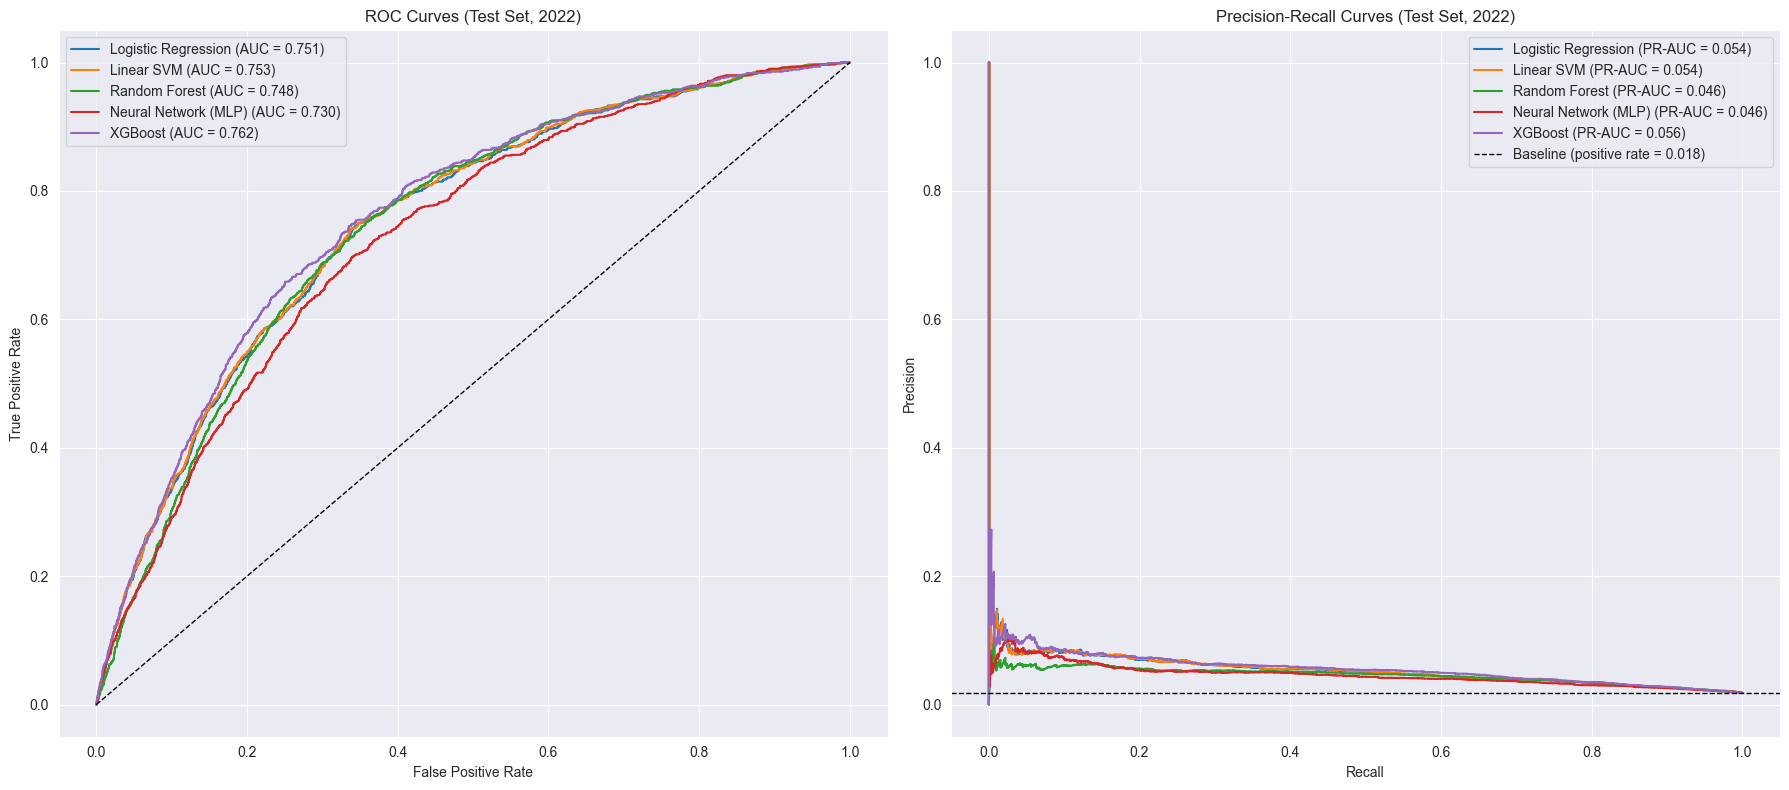

In [105]:
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score,average_precision_score

model_scores = {
    "Logistic Regression":  lr_tuned_test_prob,
    "Linear SVM":           svm_test_score,
    "Random Forest":        rf_final_test_pred_prob,
    "Neural Network (MLP)": mlp_final_test_pred_prob,
    "XGBoost":              test_prob,
}

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
# ROC
for name, score in model_scores.items():
    fpr, tpr, _ = roc_curve(y_test, score)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, score):.3f})")
axes[0].plot([0, 1], [0, 1], "k--", linewidth=1)
axes[0].set_title("ROC Curves (Test Set, 2022)")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

#PR curve
baseline = y_test.mean()
for name, score in model_scores.items():
    prec, rec, _ = precision_recall_curve(y_test, score)
    axes[1].plot(rec, prec, label=f"{name} (PR-AUC = {average_precision_score(y_test, score):.3f})")
axes[1].axhline(baseline, color="k", linestyle="--", linewidth=1,
                label=f"Baseline (positive rate = {baseline:.3f})")
axes[1].set_title("Precision-Recall Curves (Test Set, 2022)")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.tight_layout()
plt.show()

In the ROC curve, all models perform above the random guessing line, suggesting that each model has some ability to rank higher-risk loans above lower-risk loans. XGBoost has the highest ROC-AUC at 0.762, followed closely by Linear SVM and Logistic Regression. However, the ROC curves are relatively close to each other, suggesting that the overall ranking performance is similar across models.

The precision-recall curve provides a more informative view for this imbalanced classification problem. All models have relatively low PR-AUC values, reflecting the difficulty of identifying rare serious delinquency cases. XGBoost still has the highest PR-AUC at 0.056, slightly above Logistic Regression and Linear SVM. Although the improvement is small, XGBoost performs best overall among the five models. The low precision levels across models also show that many loans flagged as high risk are false positives, which is expected given the low positive rate in the test set.


#### Confusion Matrix and Feature Importance for the Best Model

Based on the test set results, XGBoost has the best overall performance among the five models, with the highest ROC-AUC, PR-AUC, precision, recall, and F1-score. Therefore, I use XGBoost as the best model for further interpretation. In this section, I present the confusion matrix to examine its classification results and the feature importance plot to understand which origination variables contribute most to the model’s risk ranking.


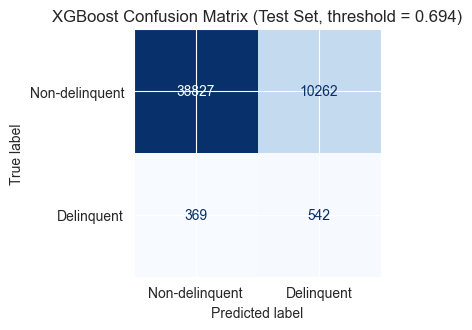

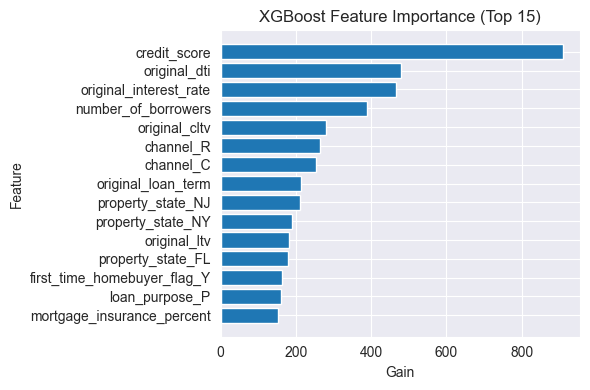

In [109]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
xgb_test_pred = (test_prob >= best_threshold).astype(int)   # best_threshold = 0.694
cm = confusion_matrix(y_test, xgb_test_pred)

fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay(cm, display_labels=["Non-delinquent", "Delinquent"]).plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
ax.set_title(f"XGBoost Confusion Matrix (Test Set, threshold = {best_threshold:.3f})")
plt.tight_layout()
plt.show()

top15 = importance.head(15).sort_values("gain")
plt.figure(figsize=(6, 4))
plt.barh(top15["feature_clean"], top15["gain"])
plt.title("XGBoost Feature Importance (Top 15)")
plt.xlabel("Gain")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

The confusion matrix shows that the XGBoost model correctly classifies 38,827 non-delinquent loans and 542 delinquent loans. The model captures 542 out of 911 actual delinquent loans, which corresponds to a recall of about 59.5%. However, it also classifies 10,262 non-delinquent loans as delinquent, indicating that many flagged high-risk loans are false positives. This is consistent with the low precision reported in the summary table and reflects the difficulty of predicting rare delinquency events.

The feature importance plot shows that `credit_score` is the most important predictor, followed by `original_dti`, `original_interest_rate`, `number_of_borrowers`, and `original_cltv`. These variables are consistent with mortgage credit risk intuition because they capture borrower credit quality, debt burden, borrowing cost, borrower structure, and leverage at origination. Several categorical variables, such as origination channel, property state, loan purpose, and first-time homebuyer status, also contribute to the model’s risk ranking.


## Discussion and Conclusions
After tuning, XGBoost performed best among the five models on the 2022 test set. It achieved the highest ROC-AUC of 0.7616, PR-AUC of 0.0562, precision of 0.0502, recall of 0.5950, and F1-score of 0.0925. Although the improvement over Linear SVM and Logistic Regression was modest, XGBoost performed best overall because it can capture nonlinear relationships and interactions among borrower credit quality, leverage, debt burden, loan pricing, property characteristics, and geographic variables. The feature importance results also align with mortgage credit risk intuition, with credit score, DTI, interest rate, number of borrowers, and CLTV contributing strongly to risk ranking.

The results show that mortgage delinquency prediction is difficult because serious delinquency is a rare event. Across all models, precision remains low, meaning that many loans predicted as delinquent are actually non-delinquent. However, recall is relatively higher, especially for XGBoost, which captures about 59.5% of the actual delinquent loans in the test set. In practice, this type of model is more useful as a risk-screening or early-warning tool than as a final decision rule. Lenders or risk managers could use the predicted scores to rank loans by risk, prioritize closer monitoring, or support portfolio-level credit risk analysis, while recognizing that many flagged loans may be false positives.

This study has several limitations. The target is based on serious delinquency within a 24-month performance window, so later delinquencies are not captured. The model also relies mainly on origination-time variables, and does not include dynamic borrower behavior, updated credit information, macroeconomic conditions, or housing market changes after origination. In addition, performance may vary across vintages and economic environments, so the results should not be interpreted as universally stable. Future work could incorporate longer performance windows, additional macroeconomic and time-varying features, probability calibration, and cost-sensitive threshold selection to improve practical credit risk decision-making.


## Reproducibility
- Software environment and key package versions are printed below.
- Random seed is fixed (`RANDOM_SEED = 42`) in the setup cell.
- The notebook is designed to run **top-to-bottom** to reproduce all results.


In [78]:
import sys, sklearn, xgboost
print("Python :", sys.version.split()[0])
print("pandas :", pd.__version__)
print("numpy  :", np.__version__)
print("sklearn:", sklearn.__version__)
print("xgboost:", xgboost.__version__)

Python : 3.9.6
pandas : 2.3.3
numpy  : 2.0.2
sklearn: 1.6.1
xgboost: 2.1.4


## References
- Freddie Mac. *Single-Family Loan-Level Dataset.* https://www.freddiemac.com/research/datasets/sf-loanlevel-dataset
